Antes de rodar crie um ambiente virtal e ative.  
Instalar o Poetry  
Executar o comando poetry lock  
Executar o comando poetry install  

# Imports

In [8]:
import pandas as pd
import plotly.express as px
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from unidecode import unidecode
from sklearn.preprocessing import StandardScaler
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.stats import zscore
from collections import defaultdict
from sklearn.decomposition import PCA
import phik
from collections import defaultdict
import math
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
from scipy.optimize import curve_fit
from sklearn.metrics import mean_squared_error, mean_absolute_error
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm


pds = pandas series  
df = DataFrame

In [9]:
warnings.filterwarnings("ignore", message="Covariance matrix calculated using the outer product")


# Preparando o Data Frame

In [10]:
abas  = pd.ExcelFile('WDI_EXCEL/WDIEXCEL.xlsx').sheet_names
abas

['Data', 'Country', 'Series', 'country-series', 'series-time', 'footnote']

In [11]:
metadata = pd.read_excel('WDI_EXCEL/WDIEXCEL.xlsx', sheet_name=abas[2])
metadata.head()

,Series Code,Topic,Indicator Name,Short definition,Long definition,Unit of measure,Periodicity,Base Period,Other notes,Aggregation method,Limitations and exceptions,Notes from original source,General comments,Source,Statistical concept and methodology,Development relevance,Related source links,Other web links,Related indicators,License Type
0,AG.CON.FERT.PT.ZS,Environment: Agricultural production,Fertilizer consumption (% of fertilizer produc...,NaN,Fertilizer consumption measures the quantity o...,NaN,Annual,NaN,The world and regional aggregate series do not...,Weighted average,The FAO has revised the time series for fertil...,NaN,NaN,"Food and Agriculture Organization, electronic ...",Fertilizer consumption measures the quantity o...,"Factors such as the green revolution, has led ...",NaN,NaN,NaN,CC BY-4.0
1,AG.CON.FERT.ZS,Environment: Agricultural production,Fertilizer consumption (kilograms per hectare ...,NaN,Fertilizer consumption measures the quantity o...,NaN,Annual,NaN,The world and regional aggregate series do not...,Weighted average,The FAO has revised the time series for fertil...,NaN,NaN,"Food and Agriculture Organization, electronic ...",Fertilizer consumption measures the quantity o...,"Factors such as the green revolution, has led ...",NaN,NaN,NaN,CC BY-4.0
2,AG.LND.AGRI.K2,Environment: Land use,Agricultural land (sq. km),NaN,Agricultural land refers to the share of land ...,NaN,Annual,NaN,Areas of former states are included in the suc...,Sum,The data are collected by the Food and Agricul...,NaN,NaN,"Food and Agriculture Organization, electronic ...",Agricultural land constitutes only a part of a...,Agricultural land covers more than one-third o...,NaN,NaN,NaN,CC BY-4.0
3,AG.LND.AGRI.ZS,Environment: Land use,Agricultural land (% of land area),NaN,Agricultural land refers to the share of land ...,NaN,Annual,NaN,Areas of former states are included in the suc...,Weighted average,The data are collected by the Food and Agricul...,NaN,NaN,"Food and Agriculture Organization, electronic ...",Agriculture is still a major sector in many ec...,Agricultural land covers more than one-third o...,NaN,NaN,NaN,CC BY-4.0
4,AG.LND.ARBL.HA,Environment: Land use,Arable land (hectares),NaN,Arable land (in hectares) includes land define...,NaN,Annual,NaN,NaN,NaN,The Food and Agriculture Organization (FAO) tr...,NaN,NaN,"Food and Agriculture Organization, electronic ...",Temporary fallow land refers to land left fall...,Agricultural land covers more than one-third o...,NaN,NaN,NaN,CC BY-4.0


In [12]:
metadata.columns = [col.strip().replace("_", " ") for col in metadata.columns]

In [13]:
metadata["Topic"].nunique()

88

In [14]:
lista_metadata = list(metadata["Topic"].unique())

In [15]:
metadata["Indicator Name"].nunique()

1496

In [16]:
dados = pd.read_excel('WDI_EXCEL/WDIEXCEL.xlsx', sheet_name=abas[0])
dados.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,Africa Eastern and Southern,AFE,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,17.488497,18.001597,18.558234,19.043572,19.586457,20.192064,20.828814,21.372164,22.100884,NaN
1,Africa Eastern and Southern,AFE,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.RU.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,6.811504,7.096003,7.406706,7.666648,8.020952,8.403358,8.718306,9.097176,9.473374,NaN
2,Africa Eastern and Southern,AFE,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.UR.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,38.152090,38.488233,38.779953,39.068462,39.445526,39.818645,40.276374,40.687817,41.211606,NaN
3,Africa Eastern and Southern,AFE,Access to electricity (% of population),EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,31.871956,33.922276,38.859598,40.223744,43.035073,44.390861,46.282371,48.127211,48.742043,NaN
4,Africa Eastern and Southern,AFE,"Access to electricity, rural (% of rural popul...",EG.ELC.ACCS.RU.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,17.672943,16.527554,24.627753,25.432092,27.061929,29.154282,31.022083,32.809138,33.760782,NaN


In [17]:
dados.columns = [col.strip().replace("_", " ") for col in dados.columns]

In [18]:
print(dados.columns)


Index(['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code',
       '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968',
       '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977',
       '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986',
       '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995',
       '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004',
       '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013',
       '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022',
       '2023'],
      dtype='object')


In [19]:
dados["Indicator Name"].nunique()

1496

In [20]:
dados_long = dados.melt(
    id_vars=["Country Name", "Country Code", "Indicator Name", "Indicator Code"],
    var_name="Year",
    value_name="Value"
)

In [21]:
dados_long["Year"] = dados_long["Year"].astype(int)

In [22]:
dados_long.dtypes

Country Name       object
Country Code       object
Indicator Name     object
Indicator Code     object
Year                int64
Value             float64
dtype: object

## Separando por paises e comaçando a olhar o data frame do Brasil

Separação feita desta maneira para uma posssivel extrapolação para demais paises futuramente

In [23]:
paises_unicos = dados_long["Country Name"].unique()

sub_dfs_por_pais = {
    pais: grupo.drop(columns=["Country Code", "Country Name"]).reset_index(drop=True)
    for pais, grupo in dados_long.groupby("Country Name")
}

brasil = sub_dfs_por_pais["Brazil"]
print("\nDados do Brasil:")
brasil.head()


Dados do Brasil:


,Indicator Name,Indicator Code,Year,Value
0,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.ZS,1960,NaN
1,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.RU.ZS,1960,NaN
2,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.UR.ZS,1960,NaN
3,Access to electricity (% of population),EG.ELC.ACCS.ZS,1960,NaN
4,"Access to electricity, rural (% of rural popul...",EG.ELC.ACCS.RU.ZS,1960,NaN


# Analise do Brasil

## Explorando e preparando o data frame para analise

In [24]:
# 1. Filtrar apenas as colunas importantes para a pivotagem
df_brasil = brasil[["Year", "Indicator Name", "Value"]].copy()

# 2. Pivotar para ficar no formato "wide" (uma coluna por indicador)
df_brasil_wide = df_brasil.pivot(
    index="Year",
    columns="Indicator Name",
    values="Value"
)

# 3. Ordenar pelas datas (anos) e exibir as primeiras linhas
df_brasil_wide.sort_index(inplace=True)
df_brasil_wide.head()

Indicator Name,ARI treatment (% of children under 5 taken to a health provider),Access to clean fuels and technologies for cooking (% of population),"Access to clean fuels and technologies for cooking, rural (% of rural population)","Access to clean fuels and technologies for cooking, urban (% of urban population)",Access to electricity (% of population),"Access to electricity, rural (% of rural population)","Access to electricity, urban (% of urban population)",Account ownership at a financial institution or with a mobile-money-service provider (% of population ages 15+),"Account ownership at a financial institution or with a mobile-money-service provider, female (% of population ages 15+)","Account ownership at a financial institution or with a mobile-money-service provider, male (% of population ages 15+)",...,Women who believe a husband is justified in beating his wife (any of five reasons) (%),Women who believe a husband is justified in beating his wife when she argues with him (%),Women who believe a husband is justified in beating his wife when she burns the food (%),Women who believe a husband is justified in beating his wife when she goes out without telling him (%),Women who believe a husband is justified in beating his wife when she neglects the children (%),Women who believe a husband is justified in beating his wife when she refuses sex with him (%),Women who were first married by age 15 (% of women ages 20-24),Women who were first married by age 18 (% of women ages 20-24),Women's share of population ages 15+ living with HIV (%),Young people (ages 15-24) newly infected with HIV
Year,,,,,,,,,,,,,,,,,,,,,
1960,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1961,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1962,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1963,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1964,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [25]:
pds_br_tps = df_brasil_wide.dtypes
for i ,formato in pds_br_tps.items():
    if formato != 'float64' and formato != 'int64':
        print(i, formato)

In [26]:
# Informações gerais sobre nulos e dimensões
linhas, colunas = df_brasil_wide.shape
total_celulas = linhas * colunas
total_nulos = df_brasil_wide.isnull().sum().sum()
porcentagem_nulos = (total_nulos / total_celulas) * 100

print(f"Linhas: {linhas}")
print(f"Colunas: {colunas}")
print(f"Total de valores nulos: {total_nulos}")


Linhas: 64
Colunas: 1496
Total de valores nulos: 49579


### Verificando quantidade de nulos por indicador

In [27]:
# Contar valores nulos por linha
pds_nulos_por_indicador = df_brasil_wide.isna().sum(axis=0)

# Exibir o resultado
print("Quantidade de valores nulos por linha (ano):")
print(pds_nulos_por_indicador.sort_values(ascending=False))

Quantidade de valores nulos por linha (ano):
Indicator Name
Young people (ages 15-24) newly infected with HIV                                                                                              64
Women making their own informed decisions regarding sexual relations, contraceptive use and reproductive health care (% of women age 15-49)    64
Domestic credit provided by financial sector (% of GDP)                                                                                        64
Proportion of women subjected to physical and/or sexual violence in the last 12 months (% of ever-partnered women ages 15-49)                  64
Educational attainment, at least completed post-secondary, population 25+, female (%) (cumulative)                                             64
                                                                                                                                               ..
Imports of goods and services (current US$)                     

In [28]:
pds_nulos_por_indicador = pds_nulos_por_indicador.sort_values(ascending=False)
indicadroes_sem_dados = []
for indicador, valor in pds_nulos_por_indicador.items():
    if valor == 64:
        indicadroes_sem_dados.append(indicador)
print(len(indicadroes_sem_dados))

102


In [29]:
new_df_brasil_wide = df_brasil_wide.drop(columns=indicadroes_sem_dados)
new_df_brasil_wide.head()

Indicator Name,ARI treatment (% of children under 5 taken to a health provider),Access to clean fuels and technologies for cooking (% of population),"Access to clean fuels and technologies for cooking, rural (% of rural population)","Access to clean fuels and technologies for cooking, urban (% of urban population)",Access to electricity (% of population),"Access to electricity, rural (% of rural population)","Access to electricity, urban (% of urban population)",Account ownership at a financial institution or with a mobile-money-service provider (% of population ages 15+),"Account ownership at a financial institution or with a mobile-money-service provider, female (% of population ages 15+)","Account ownership at a financial institution or with a mobile-money-service provider, male (% of population ages 15+)",...,"Wage and salaried workers, female (% of female employment) (modeled ILO estimate)","Wage and salaried workers, male (% of male employment) (modeled ILO estimate)","Wage and salaried workers, total (% of total employment) (modeled ILO estimate)",Wanted fertility rate (births per woman),"Water productivity, total (constant 2015 US$ GDP per cubic meter of total freshwater withdrawal)",Wholesale price index (2010 = 100),Women Business and the Law Index Score (scale 1-100),Women who were first married by age 15 (% of women ages 20-24),Women who were first married by age 18 (% of women ages 20-24),Women's share of population ages 15+ living with HIV (%)
Year,,,,,,,,,,,,,,,,,,,,,
1960,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1.768224e-13,NaN,NaN,NaN,NaN
1961,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,2.446007e-13,NaN,NaN,NaN,NaN
1962,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,3.748121e-13,NaN,NaN,NaN,NaN
1963,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,6.508432e-13,NaN,NaN,NaN,NaN
1964,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1.247164e-12,NaN,NaN,NaN,NaN


In [30]:
# Substituir zeros por NaN (sem alterar o original ainda)
df_temp = new_df_brasil_wide.replace(0, np.nan)

# Contar valores nulos (incluindo os zeros que viraram NaN) por coluna
pds_nulos_por_indicador = df_temp.isna().sum(axis=0)

# Ordenar indicadores com mais "dados faltantes"
pds_nulos_por_indicador = pds_nulos_por_indicador.sort_values(ascending=False)

# Selecionar indicadores com >= 30% de valores faltantes
limite = new_df_brasil_wide.shape[0] * 0.3  # 30% do total de anos (ex: 64)
indicadores_remover = [
    indicador for indicador, nulos in pds_nulos_por_indicador.items()
    if nulos >= limite
]

print(f"{len(indicadores_remover)} indicadores com >= 30% de NaNs ou Zeros")


911 indicadores com >= 30% de NaNs ou Zeros


In [31]:
new_df_brasil_wide = new_df_brasil_wide.drop(columns=indicadores_remover)
new_df_brasil_wide.head()

Indicator Name,Adjusted net national income (annual % growth),Adjusted net national income (constant 2015 US$),Adjusted net national income (current US$),Adjusted net national income per capita (annual % growth),Adjusted net national income per capita (constant 2015 US$),Adjusted net national income per capita (current US$),Adjusted savings: consumption of fixed capital (% of GNI),Adjusted savings: consumption of fixed capital (current US$),Adjusted savings: education expenditure (% of GNI),Adjusted savings: education expenditure (current US$),...,Travel services (% of commercial service exports),Travel services (% of commercial service imports),"Travel services (% of service exports, BoP)","Travel services (% of service imports, BoP)","Unemployment, total (% of total labor force) (national estimate)",Urban population,Urban population (% of total population),Urban population growth (annual %),Wholesale price index (2010 = 100),Women Business and the Law Index Score (scale 1-100)
Year,,,,,,,,,,,,,,,,,,,,,
1960,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,33399157.0,46.139,NaN,1.768224e-13,NaN
1961,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,35155579.0,47.122,5.125267,2.446007e-13,NaN
1962,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,36971452.0,48.099,5.036272,3.748121e-13,NaN
1963,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,38852223.0,49.078,4.961925,6.508432e-13,NaN
1964,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,40792376.0,50.059,4.872991,1.247164e-12,NaN


### Verificando quantidade de nulos por ano

In [32]:
# Contar valores nulos por linha
pds_nulos_por_ano = new_df_brasil_wide.isna().sum(axis=1)

# Exibir o resultado
print("Quantidade de valores nulos por linha (ano):")
print(pds_nulos_por_ano)

Quantidade de valores nulos por linha (ano):
Year
1960    257
1961    219
1962    205
1963    203
1964    202
       ... 
2019      6
2020      6
2021     31
2022     65
2023    133
Length: 64, dtype: int64


In [33]:
pds_nulos_por_ano = pds_nulos_por_ano.sort_values(ascending=False)
anos_remover = []
for indicador, valor in pds_nulos_por_ano.items():
    if valor >= (497*0.3):
        anos_remover.append(indicador)
print(len(anos_remover))

10


In [34]:
anos_remover.sort()
anos_remover

[1960, 1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969]

In [35]:
new_df_brasil_wide = new_df_brasil_wide.drop(labels=anos_remover, axis=0)
new_df_brasil_wide.head()

Indicator Name,Adjusted net national income (annual % growth),Adjusted net national income (constant 2015 US$),Adjusted net national income (current US$),Adjusted net national income per capita (annual % growth),Adjusted net national income per capita (constant 2015 US$),Adjusted net national income per capita (current US$),Adjusted savings: consumption of fixed capital (% of GNI),Adjusted savings: consumption of fixed capital (current US$),Adjusted savings: education expenditure (% of GNI),Adjusted savings: education expenditure (current US$),...,Travel services (% of commercial service exports),Travel services (% of commercial service imports),"Travel services (% of service exports, BoP)","Travel services (% of service imports, BoP)","Unemployment, total (% of total labor force) (national estimate)",Urban population,Urban population (% of total population),Urban population growth (annual %),Wholesale price index (2010 = 100),Women Business and the Law Index Score (scale 1-100)
Year,,,,,,,,,,,,,,,,,,,,,
1970,NaN,3.291109e+11,3.782767e+10,NaN,3450.680697,396.617704,9.121553,3.806293e+09,3.599282,1.501929e+09,...,NaN,NaN,NaN,NaN,NaN,53323573.0,55.909,4.221541,5.881536e-12,31.250
1971,11.844305,3.680918e+11,4.418975e+10,9.139582,3766.058479,452.118667,9.018367,4.390516e+09,3.599282,1.752280e+09,...,NaN,NaN,NaN,NaN,NaN,55607782.0,56.894,4.194465,7.057843e-12,31.250
1972,12.509426,4.141380e+11,5.269725e+10,9.804705,4135.309393,526.200059,9.028985,5.243614e+09,3.599282,2.090295e+09,...,NaN,NaN,NaN,NaN,3.06,57963965.0,57.879,4.149837,8.369877e-12,31.250
1973,14.291462,4.733244e+11,7.074687e+10,11.557651,4613.254011,689.534076,9.501022,7.446978e+09,3.000000,2.351424e+09,...,NaN,NaN,NaN,NaN,2.78,60385804.0,58.855,4.093252,9.772397e-12,31.250
1974,6.152843,5.024473e+11,9.352216e+10,3.638966,4781.128777,889.927177,9.749445,1.017117e+10,3.599282,3.754972e+09,...,NaN,NaN,NaN,NaN,NaN,62870949.0,59.826,4.033015,1.262268e-11,28.125


In [36]:
colunas_preservadas = new_df_brasil_wide[['Population growth (annual %)', 'Population, total']].copy()

In [37]:
new_df_brasil_wide = new_df_brasil_wide.drop(colunas_preservadas, axis=1)

In [38]:
new_df_brasil_wide.info()

<class 'pandas.core.frame.DataFrame'>
Index: 54 entries, 1970 to 2023
Columns: 481 entries, Adjusted net national income (annual % growth) to Women Business and the Law Index Score (scale 1-100)
dtypes: float64(481)
memory usage: 203.3 KB


In [39]:
new_df_brasil_wide.describe()

Indicator Name,Adjusted net national income (annual % growth),Adjusted net national income (constant 2015 US$),Adjusted net national income (current US$),Adjusted net national income per capita (annual % growth),Adjusted net national income per capita (constant 2015 US$),Adjusted net national income per capita (current US$),Adjusted savings: consumption of fixed capital (% of GNI),Adjusted savings: consumption of fixed capital (current US$),Adjusted savings: education expenditure (% of GNI),Adjusted savings: education expenditure (current US$),...,Travel services (% of commercial service exports),Travel services (% of commercial service imports),"Travel services (% of service exports, BoP)","Travel services (% of service imports, BoP)","Unemployment, total (% of total labor force) (national estimate)",Urban population,Urban population (% of total population),Urban population growth (annual %),Wholesale price index (2010 = 100),Women Business and the Law Index Score (scale 1-100)
count,51.000000,5.200000e+01,5.200000e+01,51.000000,52.000000,52.000000,52.000000,5.200000e+01,52.000000,5.200000e+01,...,49.000000,49.000000,49.000000,49.000000,45.000000,5.400000e+01,54.000000,54.000000,5.200000e+01,54.000000
mean,3.010929,9.162268e+11,6.681062e+11,1.425942,5590.578090,3682.081997,14.456639,1.461168e+11,4.417439,4.287812e+10,...,17.097469,19.294171,16.320850,18.161931,7.394556,1.256833e+08,75.951296,2.385401,5.155756e+01,57.060185
std,6.368678,3.304046e+11,5.915988e+11,6.130710,916.290481,2801.135806,3.945016,1.645337e+11,0.982101,4.571928e+10,...,9.433232,7.152482,9.000527,7.024541,3.469044,4.176731e+07,9.722235,1.177507,6.612087e+01,22.270061
min,-14.620223,3.291109e+11,3.782767e+10,-16.131683,3450.680697,396.617704,9.018367,3.806293e+09,2.800000,1.501929e+09,...,2.366505,6.648368,2.262181,5.898268,1.920000,5.332357e+07,55.909000,0.632380,5.881536e-12,28.125000
25%,-0.211241,6.445987e+11,1.925976e+11,-1.653632,4987.951719,1490.704292,11.792705,2.432008e+10,3.599282,7.718184e+09,...,7.535885,14.728987,7.253886,13.296869,4.040000,8.921814e+07,68.359000,1.201713,1.327366e-09,33.125000
50%,3.097826,9.307267e+11,4.434869e+11,1.276949,5542.382954,2537.679504,13.756643,7.698704e+10,4.264303,2.063184e+10,...,17.807276,19.942503,17.324395,18.475186,7.578000,1.301583e+08,78.675000,2.422724,2.191907e+01,50.625000
75%,5.882612,1.271165e+12,1.160585e+12,4.064897,6433.397369,5848.704142,15.720799,2.527057e+11,5.217500,8.456528e+10,...,23.862175,24.342780,22.045219,22.862175,10.150000,1.628768e+08,84.262250,3.513118,9.463679e+01,81.875000
max,22.522958,1.435186e+12,2.003637e+12,20.438679,7230.947942,10260.080844,23.062757,5.187513e+11,6.281311,1.399386e+11,...,39.869707,35.950176,39.080460,34.497130,13.697000,1.853562e+08,87.788000,4.221541,2.752110e+02,85.000000


### Verificando indicadores redundantes

In [40]:
import pandas as pd
import numpy as np

# Preencher NaNs (por exemplo com interpolação linear)
df = new_df_brasil_wide.interpolate(method='linear', limit_direction='both')

# Padronizar os dados
df_zscore = df.apply(zscore)

# Função para calcular a correlação cruzada entre duas séries
def max_cross_corr(series1, series2, max_lag=5):
    lags = range(-max_lag, max_lag + 1)
    corrs = [series1.corr(series2.shift(lag)) for lag in lags]
    max_corr = max(corrs, key=abs)
    return max_corr

# Parâmetros
threshold = 0.9  # Correlação cruzada acima desse valor será considerada redundância
max_lag = 5      # Número máximo de anos de defasagem

# Detectar pares altamente correlacionados com defasagem
to_remove = set()
columns = df_zscore.columns.tolist()

for i, col1 in enumerate(columns):
    for col2 in columns[i+1:]:
        corr = max_cross_corr(df_zscore[col1], df_zscore[col2], max_lag=max_lag)
        if abs(corr) > threshold:
            to_remove.add(col2)

# Remover colunas redundantes
new_df_brasil_wide = df.drop(columns=to_remove)

print(f"\n{len(to_remove)} variáveis removidas por correlação cruzada.")

c:\Users\lucas\AppData\Local\pypoetry\Cache\virtualenvs\sme0852-n9wiItl1-py3.13\Lib\site-packages\pandas\core\apply.py:1081: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  results[i] = self.func(v, *self.args, **self.kwargs)
c:\Users\lucas\AppData\Local\pypoetry\Cache\virtualenvs\sme0852-n9wiItl1-py3.13\Lib\site-packages\pandas\core\apply.py:1081: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  results[i] = self.func(v, *self.args, **self.kwargs)
c:\Users\lucas\AppData\Local\pypoetry\Cache\virtualenvs\sme0852-n9wiItl1-py3.13\Lib\site-packages\pandas\core\apply.py:1081: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  


345 variáveis removidas por correlação cruzada.


###  Verificando df

In [41]:
new_df_brasil_wide = pd.concat([new_df_brasil_wide, colunas_preservadas], axis=1)

In [42]:
new_df_brasil_wide.head()

Indicator Name,Adjusted net national income (annual % growth),Adjusted net national income (constant 2015 US$),Adjusted savings: education expenditure (% of GNI),Adjusted savings: energy depletion (% of GNI),Adjusted savings: gross savings (% of GNI),Adjusted savings: mineral depletion (% of GNI),Adjusted savings: net national savings (% of GNI),Adjusted savings: net national savings (current US$),"Adolescent fertility rate (births per 1,000 women ages 15-19)",Agricultural land (% of land area),...,Short-term debt (% of total external debt),Short-term debt (% of total reserves),Surface area (sq. km),Terms of trade adjustment (constant LCU),Total debt service (% of GNI),"Total debt service (% of exports of goods, services and primary income)",Travel services (% of commercial service exports),Travel services (% of commercial service imports),Population growth (annual %),"Population, total"
Year,,,,,,,,,,,,,,,,,,,,,
1970,11.844305,3.291109e+11,3.599282,0.047728,21.837114,0.178979,11.209303,1.367722e+10,75.066,22.771574,...,11.9318,60.006561,8515770.0,1.385222e+10,1.838590,43.829105,7.259714,17.629816,2.473172,95375651.0
1971,11.844305,3.680918e+11,3.599282,0.070111,21.837114,0.143288,11.209303,1.367722e+10,76.733,23.191045,...,11.9465,52.627887,8515770.0,1.067689e+10,1.805230,43.829105,7.259714,17.629816,2.448014,97739273.0
1972,12.509426,4.141380e+11,3.599282,0.066085,21.837114,0.165481,11.209303,1.367722e+10,79.207,23.610516,...,11.9275,33.541404,8515770.0,1.393160e+10,2.072381,43.829105,7.259714,17.629816,2.433363,100146797.0
1973,14.291462,4.733244e+11,3.000000,0.088562,21.837114,0.149967,11.209303,1.367722e+10,80.863,24.029988,...,11.9544,27.670790,8515770.0,2.787188e+10,2.453171,43.829105,7.259714,17.629816,2.421037,102600976.0
1974,6.152843,5.024473e+11,3.599282,0.388249,21.837114,0.217802,11.209303,1.367722e+10,81.322,24.449459,...,12.0278,49.458973,8515770.0,8.881354e+09,3.282392,43.829105,7.259714,17.629816,2.396659,105089675.0


In [43]:
# 1) Ver a lista completa
new_df_brasil_wide.columns          # retorna um Index

# 2) Transformar em lista Python
indicadores = new_df_brasil_wide.columns.tolist()
print(indicadores)

# 3) Mostrar uma por linha (útil quando são muitas)
for col in new_df_brasil_wide.columns:
    print(col)

# 4) Resumo rápido
new_df_brasil_wide.info()           # mostra nº de colunas e tipos


['Adjusted net national income (annual % growth)', 'Adjusted net national income (constant 2015 US$)', 'Adjusted savings: education expenditure (% of GNI)', 'Adjusted savings: energy depletion (% of GNI)', 'Adjusted savings: gross savings (% of GNI)', 'Adjusted savings: mineral depletion (% of GNI)', 'Adjusted savings: net national savings (% of GNI)', 'Adjusted savings: net national savings (current US$)', 'Adolescent fertility rate (births per 1,000 women ages 15-19)', 'Agricultural land (% of land area)', 'Agricultural raw materials exports (% of merchandise exports)', 'Agricultural raw materials imports (% of merchandise imports)', 'Agriculture, forestry, and fishing, value added (annual % growth)', 'Arable land (hectares per person)', 'Arms exports (SIPRI trend indicator values)', 'Arms imports (SIPRI trend indicator values)', 'Average precipitation in depth (mm per year)', 'Broad money (% of GDP)', 'Broad money growth (annual %)', 'Broad money to total reserves ratio', 'Capture f

In [44]:
new_df_brasil_wide.info()

<class 'pandas.core.frame.DataFrame'>
Index: 54 entries, 1970 to 2023
Columns: 138 entries, Adjusted net national income (annual % growth) to Population, total
dtypes: float64(138)
memory usage: 58.6 KB


In [45]:
# Informações gerais sobre nulos e dimensões
linhas, colunas = new_df_brasil_wide.shape
total_celulas = linhas * colunas
total_nulos = new_df_brasil_wide.isnull().sum().sum()
porcentagem_nulos = (total_nulos / total_celulas) * 100

print(f"Linhas: {linhas}")
print(f"Colunas: {colunas}")
print(f"Total de valores nulos: {total_nulos}")


Linhas: 54
Colunas: 138
Total de valores nulos: 0


# Análise Exploratória

## Agrupamento de topicos

### Topico com subtopico

In [46]:
# Filtra indicadores da metadata que estão no df_brasil_wide
metadata_filtered = metadata[metadata["Indicator Name"].isin(new_df_brasil_wide.columns)]

# Agrupa por tópico
agrupamentos_por_topico = (
    metadata_filtered.groupby("Topic")["Indicator Name"]
    .apply(list)
    .to_dict()
)


In [47]:
x = []
for topico in agrupamentos_por_topico.keys():
    z = []
    for item in agrupamentos_por_topico[topico]:
      z.append(item)
    x.append(len(z))
print(x)

[5, 3, 1, 2, 1, 8, 1, 11, 8, 8, 1, 3, 9, 2, 18, 1, 1, 2, 1, 1, 1, 6, 2, 4, 1, 3, 1, 2, 1, 9, 8, 3, 1]


In [48]:
# 3. Cria um dicionário de DataFrames por tópico
dfs_por_topico = {}

for topico, indicadores in agrupamentos_por_topico.items():
    # Garante que os indicadores existem no DataFrame
    indicadores_validos = [ind for ind in indicadores if ind in new_df_brasil_wide.columns]

    if indicadores_validos:
        df_topico = new_df_brasil_wide[indicadores_validos].copy()
        dfs_por_topico[topico] = df_topico


In [49]:
diagnostico_topico = []

for topico, df in dfs_por_topico.items():
    df_clean = df.dropna(axis=1, how='all').dropna()  # remove colunas completamente nulas e linhas com NA

    if df_clean.empty:
        continue

    # Padroniza os dados
    scaler = StandardScaler()
    df_scaled = pd.DataFrame(scaler.fit_transform(df_clean), columns=df_clean.columns)

    # Contagem total de outliers (z-score > 3)
    outliers_mask = df_scaled.abs() > 3
    n_outliers_total = outliers_mask.sum().sum()

    # Quantas variáveis têm ao menos 1 outlier
    n_vars_outlier = (outliers_mask.sum() > 0).sum()
    pct_vars_outlier = round((n_vars_outlier / len(df_clean)), 2)

    # Correlações
    try:
        corr_matrix = df_scaled.corr().abs()
        upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
        n_corr_alta = (upper_tri > 0.9).sum().sum()
        n_vars = df_scaled.shape[1]
        if n_vars <= 1:
            per_cent_corr = 0.0
        else:
            total_possible = n_vars * (n_vars - 1) / 2
            per_cent_corr = round((n_corr_alta / total_possible) * 100, 2)
    except:
        per_cent_corr = None

    diagnostico_topico.append({
        'Topico': topico,
        'N_Variáveis': df.shape[1],
        'N_Observações': df.shape[0],
        '% Missing': round(df.isnull().mean().mean() * 100, 2),
        '% correlações > 0.9': per_cent_corr,
        'N_Outliers (z > 3)': int(n_outliers_total),
        '% Variáveis com Outliers': pct_vars_outlier
    })

df_diag = pd.DataFrame(diagnostico_topico).sort_values('Topico', ascending=True).reset_index(drop=True)
df_diag

,Topico,N_Variáveis,N_Observações,% Missing,% correlações > 0.9,N_Outliers (z > 3),% Variáveis com Outliers
0,Economic Policy & Debt: Balance of payments: C...,5,54,0.0,0.0,5,0.07
1,Economic Policy & Debt: Balance of payments: C...,3,54,0.0,0.0,2,0.04
2,Economic Policy & Debt: Balance of payments: C...,1,54,0.0,0.0,0,0.00
3,Economic Policy & Debt: Balance of payments: C...,2,54,0.0,0.0,0,0.00
4,Economic Policy & Debt: Balance of payments: R...,1,54,0.0,0.0,1,0.02
5,Economic Policy & Debt: External debt: Debt ra...,8,54,0.0,0.0,3,0.06
6,Economic Policy & Debt: External debt: Debt se...,1,54,0.0,0.0,1,0.02
7,Economic Policy & Debt: External debt: Net flows,11,54,0.0,0.0,18,0.20
8,Economic Policy & Debt: National accounts: Adj...,8,54,0.0,0.0,5,0.06
9,Economic Policy & Debt: National accounts: Gro...,8,54,0.0,0.0,5,0.09


### Topicos macros

In [50]:
dfs_por_macrotema = defaultdict(list)

for topico, df in dfs_por_topico.items():
    macrotema = topico.split(':')[0].strip()
    dfs_por_macrotema[macrotema].append(df)


In [51]:
dfs_macrotema_unificado = {}

for macrotema, lista_dfs in dfs_por_macrotema.items():
    df_merged = pd.concat(lista_dfs, axis=1)
    # Remove colunas duplicadas (caso haja) e mantém ordem
    df_merged = df_merged.loc[:, ~df_merged.columns.duplicated()]
    dfs_macrotema_unificado[macrotema] = df_merged

In [52]:
dfs_macrotema_unificado.pop("Education", None).head(0)

Indicator Name,Lower secondary school starting age (years),"Secondary education, duration (years)"
Year,,


In [53]:
diagnostico_macrotema = []

for tema, df in dfs_macrotema_unificado.items():
    df_clean = df.dropna(axis=1, how='all').dropna()  # remove colunas completamente nulas e linhas com NA

    if df_clean.empty:
        continue

    # Padroniza os dados
    scaler = StandardScaler()
    df_scaled = pd.DataFrame(scaler.fit_transform(df_clean), columns=df_clean.columns)

    # Contagem total de outliers (z-score > 3)
    outliers_mask = df_scaled.abs() > 3
    n_outliers_total = outliers_mask.sum().sum()

    # Quantas variáveis têm ao menos 1 outlier
    n_vars_outlier = (outliers_mask.sum() > 0).sum()
    pct_vars_outlier = round((n_vars_outlier / len(df_clean)), 2)

    # Correlações
    try:
        corr_matrix = df_scaled.corr().abs()
        upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
        n_corr_alta = (upper_tri > 0.9).sum().sum()
        n_vars = df_scaled.shape[1]
        if n_vars <= 1:
            per_cent__corr = 0.0  # Ou np.nan, dependendo do que quiser representar
        else:
            total_possible = n_vars * (n_vars - 1) / 2
            per_cent__corr = round((n_corr_alta / total_possible) * 100, 2)

    except:
        per_cent__corr = None

    diagnostico_macrotema.append({
        'Macrotema': tema,
        'N_Variáveis': df.shape[1],
        'N_Observações': df.shape[0],
        '% Missing': round(df.isnull().mean().mean() * 100, 2),
        '% correlações > 0.9': per_cent__corr,
        'N_Outliers (z > 3)': int(n_outliers_total),
        '% Variáveis com Outliers': pct_vars_outlier
    })

df_diag_macro = pd.DataFrame(diagnostico_macrotema).sort_values('N_Variáveis', ascending=False)
df_diag_macro.reset_index(drop=True, inplace=True)
df_diag_macro


,Macrotema,N_Variáveis,N_Observações,% Missing,% correlações > 0.9,N_Outliers (z > 3),% Variáveis com Outliers
0,Economic Policy & Debt,81,54,0.0,0.00,65,0.91
1,Private Sector & Trade,17,54,0.0,0.00,9,0.13
2,Environment,13,54,0.0,0.00,7,0.07
3,Financial Sector,8,54,0.0,0.00,12,0.11
4,Health,4,54,0.0,16.67,0,0.00
5,Public Sector,3,54,0.0,0.00,3,0.06
6,Social Protection & Labor,1,54,0.0,0.00,0,0.00


In [54]:
px.bar(df_diag_macro, x="Macrotema", y="N_Variáveis", title="Número de Variáveis por Macrotema")


## Analise de crescimento populacional

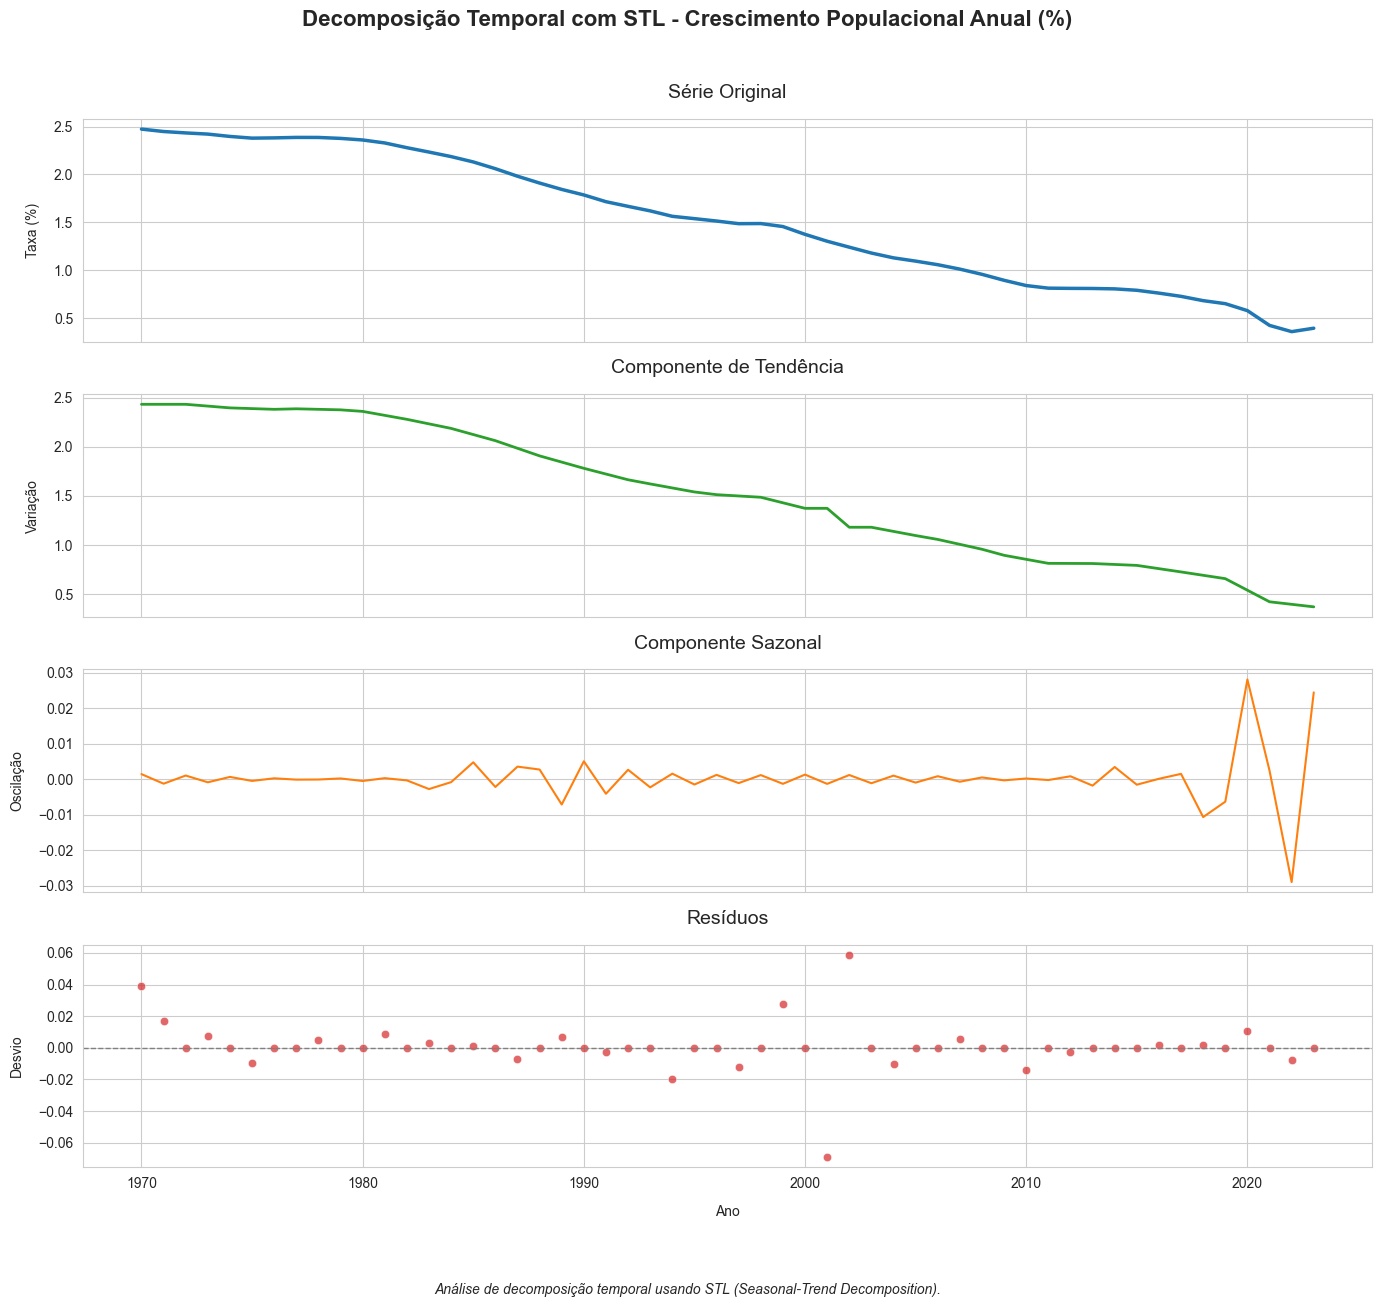

In [55]:
from statsmodels.tsa.seasonal import STL
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração de estilo mais robusta
plt.style.use('default')  # Usa o estilo padrão como base
sns.set_style("whitegrid")  # Estilo do seaborn
sns.set_palette("husl")  # Paleta de cores
plt.rcParams['figure.facecolor'] = 'white'  # Fundo branco

# Interpolação
pop_growth = new_df_brasil_wide['Population growth (annual %)'].interpolate()

# Verifica se há dados suficientes
if len(pop_growth) >= 4:
    # STL: usa o Loess para detectar tendência e sazonalidade
    stl = STL(pop_growth, period=2, robust=True)
    res = stl.fit()
    
    # Criar figura
    fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
    fig.suptitle('Decomposição Temporal com STL - Crescimento Populacional Anual (%)', 
                 y=1.02, fontsize=16, fontweight='bold')
    
    # Série original
    sns.lineplot(x=pop_growth.index, y=pop_growth, ax=axes[0], linewidth=2.5, color='#1f77b4')
    axes[0].set_title('Série Original', pad=15, fontsize=14)
    axes[0].set_ylabel('Taxa (%)', labelpad=10)
    
    # Tendência
    sns.lineplot(x=res.trend.index, y=res.trend, ax=axes[1], linewidth=2, color='#2ca02c')
    axes[1].set_title('Componente de Tendência', pad=15, fontsize=14)
    axes[1].set_ylabel('Variação', labelpad=10)
    
    # Sazonalidade
    sns.lineplot(x=res.seasonal.index, y=res.seasonal, ax=axes[2], linewidth=1.5, color='#ff7f0e')
    axes[2].set_title('Componente Sazonal', pad=15, fontsize=14)
    axes[2].set_ylabel('Oscilação', labelpad=10)
    
    # Resíduos
    sns.scatterplot(x=res.resid.index, y=res.resid, ax=axes[3], color='#d62728', alpha=0.7)
    axes[3].axhline(0, color='gray', linestyle='--', linewidth=1)
    axes[3].set_title('Resíduos', pad=15, fontsize=14)
    axes[3].set_ylabel('Desvio', labelpad=10)
    axes[3].set_xlabel('Ano', labelpad=10)
    
    # Ajuste layout
    plt.tight_layout()
    plt.figtext(0.5, -0.05, 
                "Análise de decomposição temporal usando STL (Seasonal-Trend Decomposition).",
                ha="center", fontsize=10, style='italic')
    
    plt.show()

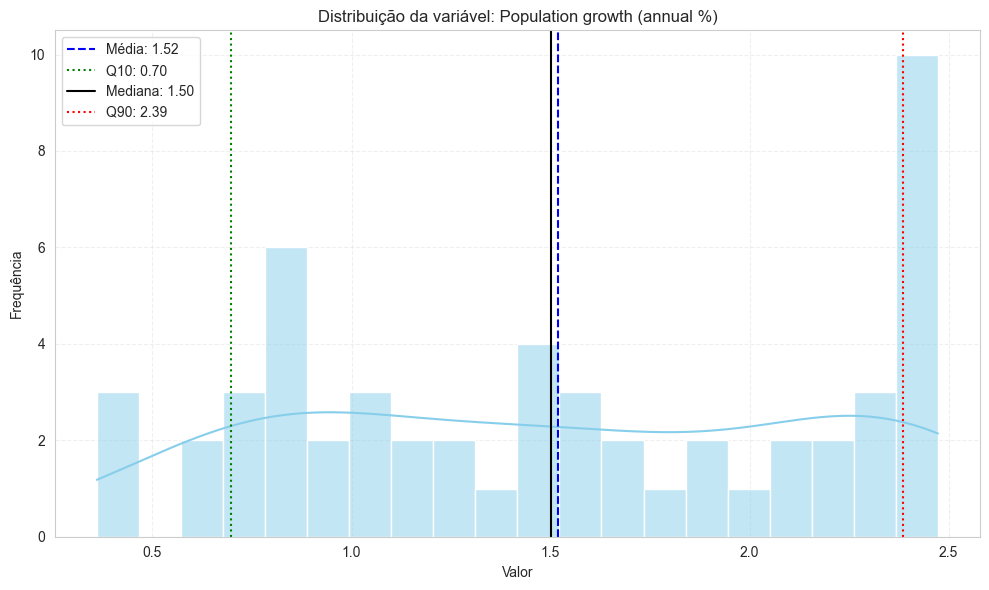

In [56]:
# Seleciona a variável
variavel = 'Population growth (annual %)'
serie = new_df_brasil_wide[variavel].dropna()

# Calcula estatísticas
media = serie.mean()
q10, mediana, q90 = np.percentile(serie, [10, 50, 90])
min_val, max_val = serie.min(), serie.max()

# Plot
plt.figure(figsize=(10, 6))
sns.histplot(serie, kde=True, color='skyblue', bins=20)
plt.axvline(media, color='blue', linestyle='--', label=f'Média: {media:.2f}')
plt.axvline(q10, color='green', linestyle=':', label=f'Q10: {q10:.2f}')
plt.axvline(mediana, color='black', linestyle='-', label=f'Mediana: {mediana:.2f}')
plt.axvline(q90, color='red', linestyle=':', label=f'Q90: {q90:.2f}')
plt.title(f'Distribuição da variável: {variavel}')
plt.xlabel('Valor')
plt.ylabel('Frequência')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


C:\Users\lucas\AppData\Local\Temp\ipykernel_2888\2557967588.py:7: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




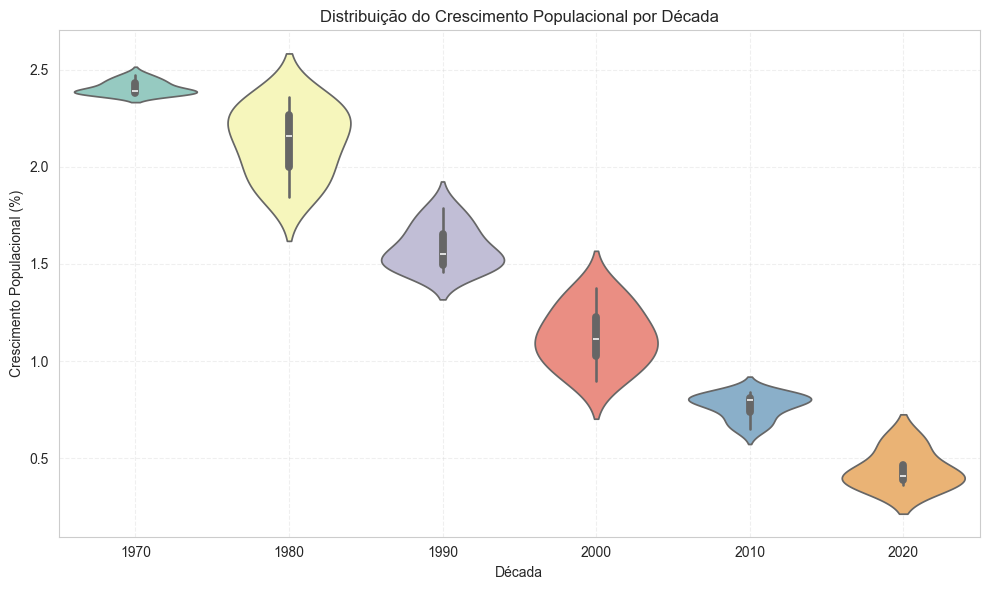

In [57]:
# Criar coluna de década
df_decada = new_df_brasil_wide.copy()
df_decada['Década'] = (df_decada.index // 10) * 10

# Plot para uma variável de interesse
plt.figure(figsize=(10, 6))
sns.violinplot(x='Década', y='Population growth (annual %)', data=df_decada.reset_index(), palette="Set3")
plt.title('Distribuição do Crescimento Populacional por Década')
plt.xlabel('Década')
plt.ylabel('Crescimento Populacional (%)')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


## Correlações

Phik por item

c:\Users\lucas\AppData\Local\pypoetry\Cache\virtualenvs\sme0852-n9wiItl1-py3.13\Lib\site-packages\phik\data_quality.py:72: UserWarning:

Not enough unique value for variable Land area (sq. km) for analysis 1. Dropping this column

c:\Users\lucas\AppData\Local\pypoetry\Cache\virtualenvs\sme0852-n9wiItl1-py3.13\Lib\site-packages\phik\data_quality.py:72: UserWarning:

Not enough unique value for variable Lower secondary school starting age (years) for analysis 1. Dropping this column

c:\Users\lucas\AppData\Local\pypoetry\Cache\virtualenvs\sme0852-n9wiItl1-py3.13\Lib\site-packages\phik\data_quality.py:72: UserWarning:

Not enough unique value for variable Renewable internal freshwater resources, total (billion cubic meters) for analysis 1. Dropping this column

c:\Users\lucas\AppData\Local\pypoetry\Cache\virtualenvs\sme0852-n9wiItl1-py3.13\Lib\site-packages\phik\data_quality.py:72: UserWarning:

Not enough unique value for variable Secondary education, duration (years) for analysis 1. Dro

interval columns not set, guessing: ['Adjusted net national income (annual % growth)', 'Adjusted net national income (constant 2015 US$)', 'Adjusted savings: education expenditure (% of GNI)', 'Adjusted savings: energy depletion (% of GNI)', 'Adjusted savings: gross savings (% of GNI)', 'Adjusted savings: mineral depletion (% of GNI)', 'Adjusted savings: net national savings (% of GNI)', 'Adjusted savings: net national savings (current US$)', 'Adolescent fertility rate (births per 1,000 women ages 15-19)', 'Agricultural land (% of land area)', 'Agricultural raw materials exports (% of merchandise exports)', 'Agricultural raw materials imports (% of merchandise imports)', 'Agriculture, forestry, and fishing, value added (annual % growth)', 'Arable land (hectares per person)', 'Arms exports (SIPRI trend indicator values)', 'Arms imports (SIPRI trend indicator values)', 'Average precipitation in depth (mm per year)', 'Broad money (% of GDP)', 'Broad money growth (annual %)', 'Broad money 

C:\Users\lucas\AppData\Local\Temp\ipykernel_2888\4049580031.py:12: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




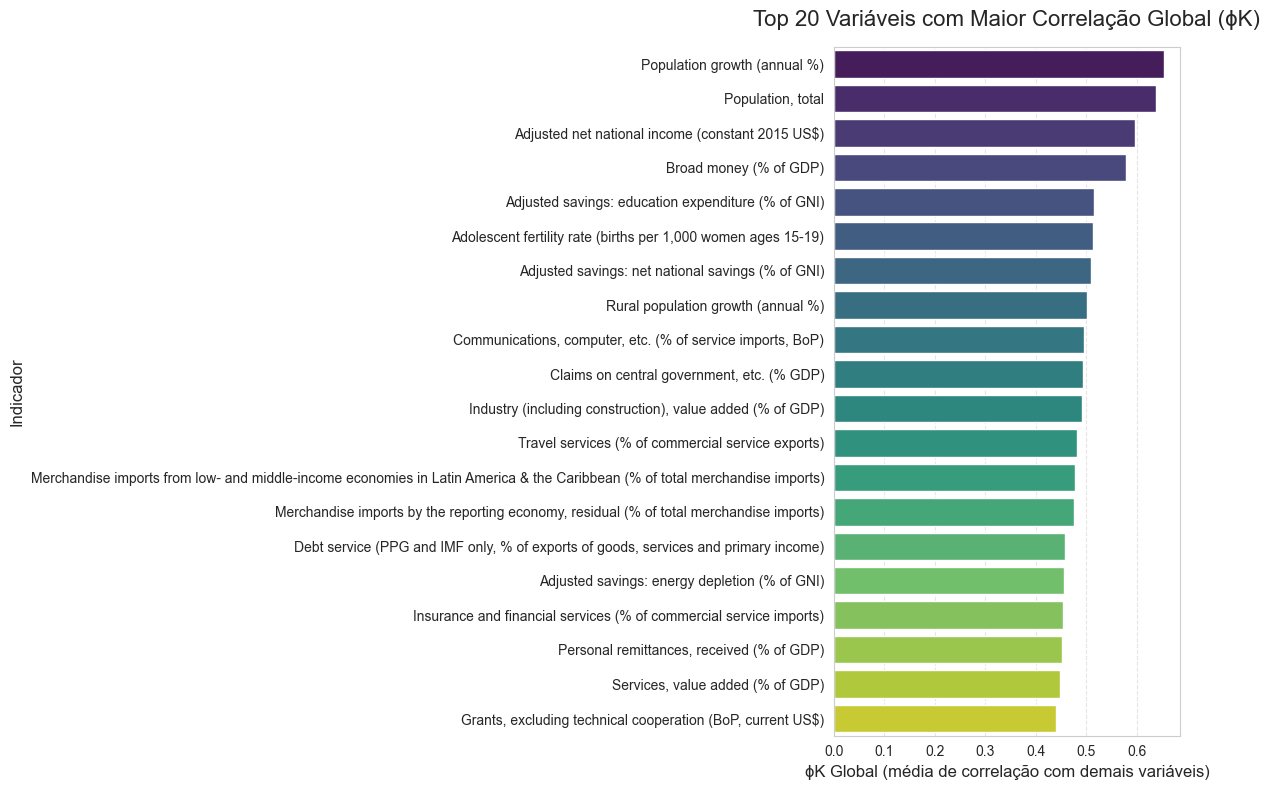

In [58]:
# Passo 1: interpolar valores faltantes
df_interp = new_df_brasil_wide.interpolate(method='linear', limit_direction='both')

# Passo 2: calcular matriz phik
phik_corr = df_interp.phik_matrix()

# Passo 3: calcular o vetor de correlação global (ϕK global)
phik_global = phik_corr.dropna(axis=0, how='all').mean(axis=1).sort_values(ascending=False)

# Passo 4: plotar o gráfico
plt.figure(figsize=(12, 8))
sns.barplot(y=phik_global.index[:20], x=phik_global.values[:20], palette='viridis')
plt.title('Top 20 Variáveis com Maior Correlação Global (ϕK)', fontsize=16, pad=15)
plt.xlabel('ϕK Global (média de correlação com demais variáveis)', fontsize=12)
plt.ylabel('Indicador', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

phik por macro tema

interval columns not set, guessing: ['Foreign direct investment, net outflows (% of GDP)', 'Net errors and omissions (BoP, current US$)', 'Reserves and related items (BoP, current US$)', 'Foreign direct investment, net inflows (% of GDP)', 'Portfolio equity, net inflows (BoP, current US$)', 'Current account balance (BoP, current US$)', 'Current account balance (% of GDP)', 'Net trade in goods (BoP, current US$)', 'Communications, computer, etc. (% of service imports, BoP)', 'Net secondary income (BoP, current US$)', 'Personal remittances, received (% of GDP)', 'Grants, excluding technical cooperation (BoP, current US$)', 'External debt stocks (% of GNI)', 'Short-term debt (% of total reserves)', 'Short-term debt (% of exports of goods, services and primary income)', 'Short-term debt (% of total external debt)', 'Total debt service (% of exports of goods, services and primary income)', 'Total debt service (% of GNI)', 'Public and publicly guaranteed debt service (% of GNI)', 'Multilater

c:\Users\lucas\AppData\Local\pypoetry\Cache\virtualenvs\sme0852-n9wiItl1-py3.13\Lib\site-packages\phik\data_quality.py:72: UserWarning:

Not enough unique value for variable Renewable internal freshwater resources, total (billion cubic meters) for analysis 1. Dropping this column

c:\Users\lucas\AppData\Local\pypoetry\Cache\virtualenvs\sme0852-n9wiItl1-py3.13\Lib\site-packages\phik\data_quality.py:72: UserWarning:

Not enough unique value for variable Land area (sq. km) for analysis 1. Dropping this column



interval columns not set, guessing: ['Arms imports (SIPRI trend indicator values)', 'Military expenditure (% of GDP)', 'Arms exports (SIPRI trend indicator values)']
interval columns not set, guessing: ['Net migration']


C:\Users\lucas\AppData\Local\Temp\ipykernel_2888\1030460313.py:25: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




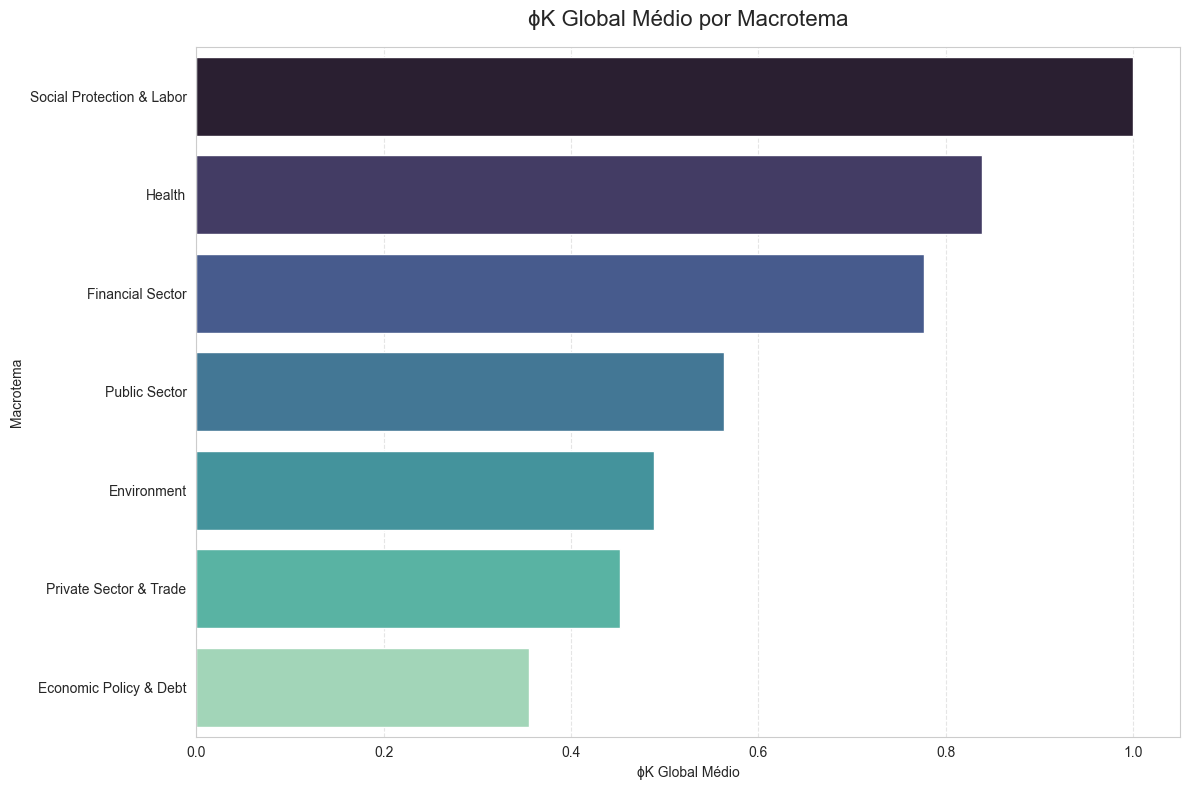

In [59]:
# Armazenar resultados
phik_macrotemas = {}

for tema, df in dfs_macrotema_unificado.items():
    # Interpola para preencher valores ausentes
    df_interp = df.interpolate(method='linear', limit_direction='both')

    try:
        # Calcula a matriz de correlação ϕK
        phik_corr = df_interp.phik_matrix()

        # Calcula o ϕK global (média das correlações de cada variável com as outras)
        phik_global_medio = phik_corr.dropna(axis=0, how='all').mean().mean()
        phik_macrotemas[tema] = phik_global_medio

    except Exception as e:
        print(f"Erro no macrotema '{tema}': {e}")

# Converter para DataFrame
phik_df = pd.DataFrame.from_dict(phik_macrotemas, orient='index', columns=['ϕK Global Médio'])
phik_df.sort_values('ϕK Global Médio', ascending=False, inplace=True)

# Plotar gráfico
plt.figure(figsize=(12, 8))
sns.barplot(x=phik_df['ϕK Global Médio'], y=phik_df.index, palette='mako')
plt.title('ϕK Global Médio por Macrotema', fontsize=16, pad=15)
plt.xlabel('ϕK Global Médio')
plt.ylabel('Macrotema')
plt.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Pear por itens

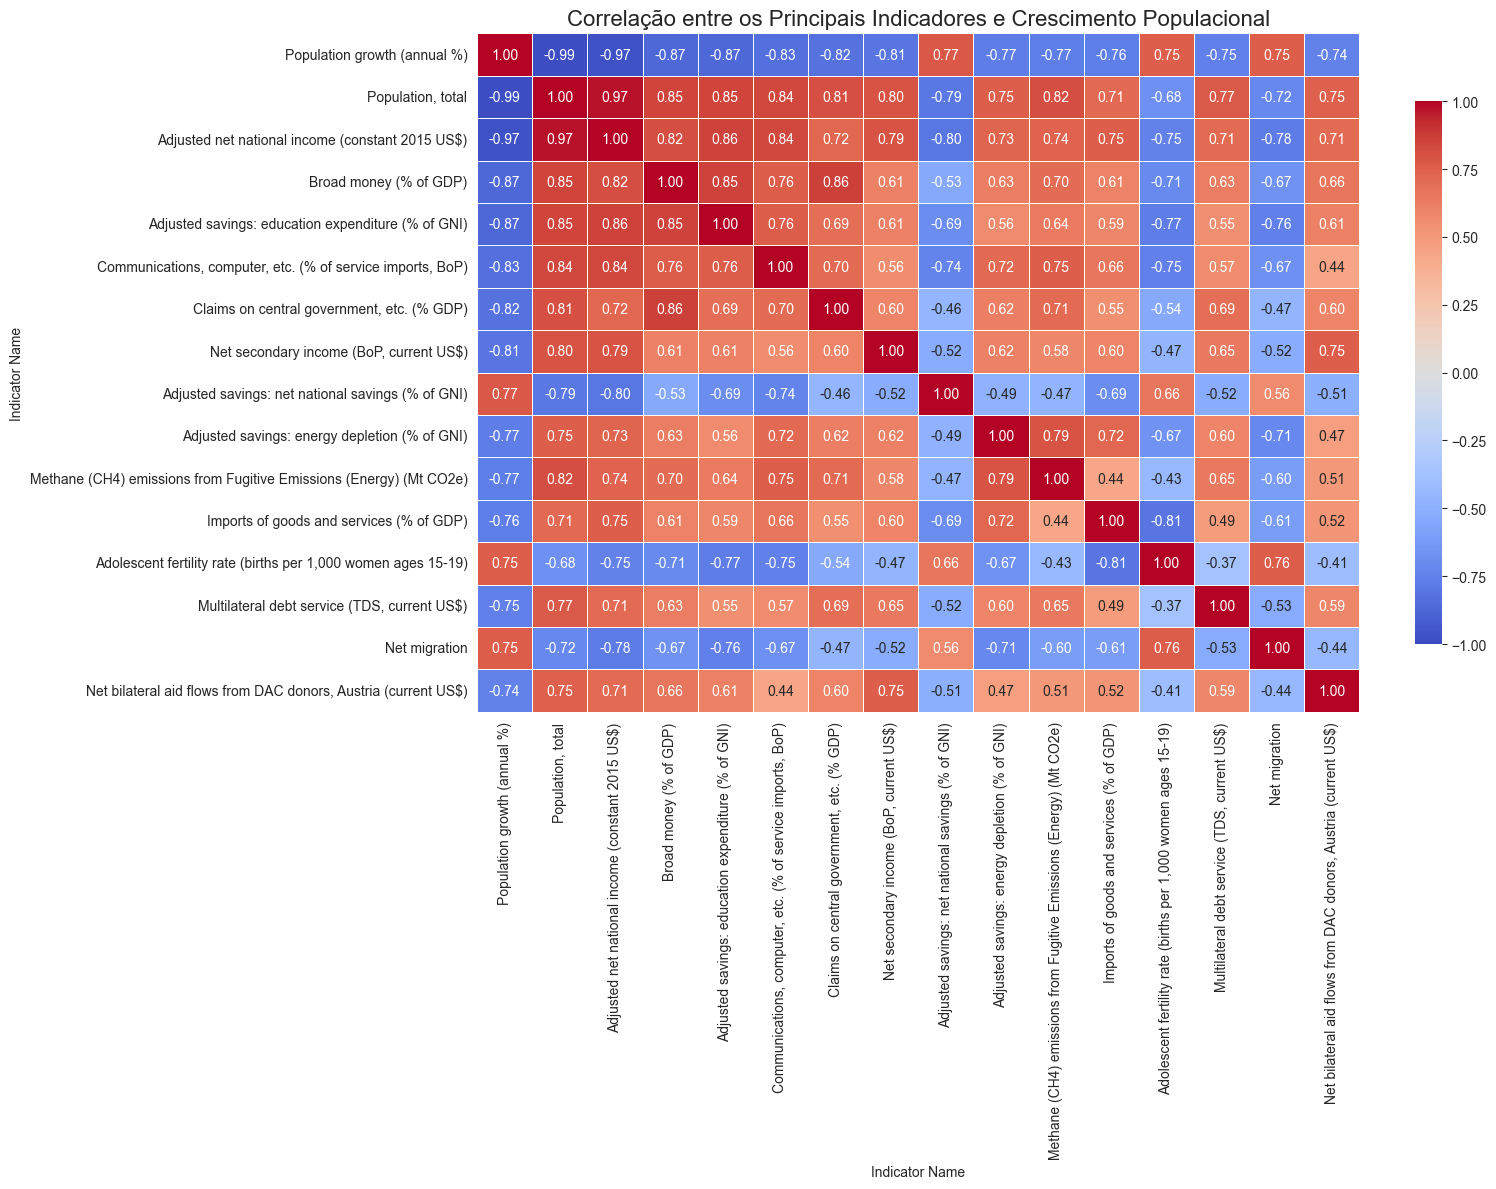

In [60]:
# 1. Análise de Correlação Avançada
plt.figure(figsize=(16, 12))
# Selecionando os 15 indicadores mais correlacionados com crescimento populacional
corr_pop = new_df_brasil_wide.corr()['Population growth (annual %)'].abs().sort_values(ascending=False)
top_15_vars = corr_pop.head(16).index
corr_matrix = new_df_brasil_wide[top_15_vars].corr()

# Máscara para triângulo superior
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1,
            fmt='.2f', linewidths=0.5, cbar_kws={"shrink": .8})
plt.title('Correlação entre os Principais Indicadores e Crescimento Populacional', fontsize=16)
plt.tight_layout()
plt.show()

pearson por macro

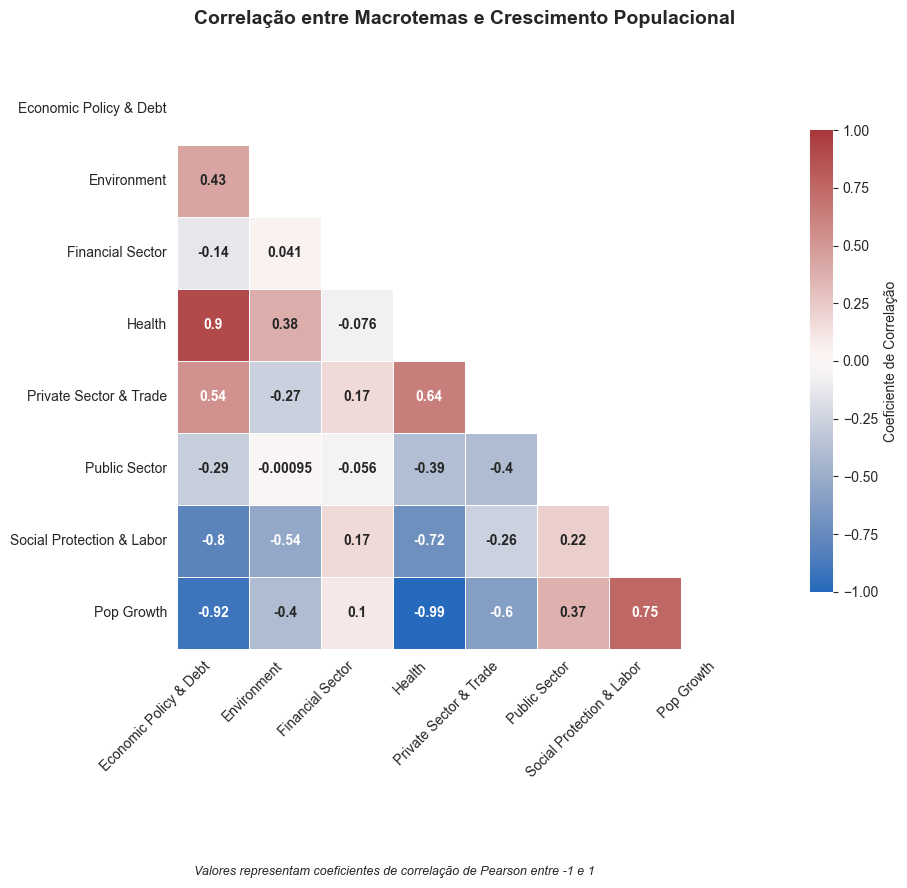

In [61]:
medias_macro = {}
for macrotema, df_macro in dfs_macrotema_unificado.items():
    df_macro_interp = df_macro.interpolate(method='linear', limit_direction='both')
    medias_macro[macrotema] = df_macro_interp.mean(axis=1)

df_macro_medias = pd.DataFrame(medias_macro)
df_macro_medias['Pop Growth'] = new_df_brasil_wide['Population growth (annual %)']
# Configurações de estilo
plt.style.use('default')
sns.set_style("white")
plt.rcParams['figure.facecolor'] = 'white'

# Criar a figura
plt.figure(figsize=(12, 8))

# Gerar a máscara para o triângulo superior (opcional)
mask = np.triu(np.ones_like(df_macro_medias.corr(), dtype=bool))

# Heatmap aprimorado
heatmap = sns.heatmap(
    df_macro_medias.corr(),
    mask=mask,  # Remover se quiser mostrar toda a matriz
    annot=True,
    annot_kws={'size': 10, 'weight': 'bold'},
    cmap='vlag',  # Alternativa: 'coolwarm', 'RdBu_r', 'icefire'
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    linecolor='white',
    square=True,
    cbar_kws={'shrink': 0.8, 'label': 'Coeficiente de Correlação'}
)

# Melhorar título
plt.title(
    "Correlação entre Macrotemas e Crescimento Populacional\n",
    fontsize=14,
    pad=20,
    fontweight='bold'
)

# Rotacionar os rótulos do eixo x
heatmap.set_xticklabels(
    heatmap.get_xticklabels(),
    rotation=45,
    horizontalalignment='right',
    fontsize=10
)

# Ajustar rótulos do eixo y
heatmap.set_yticklabels(
    heatmap.get_yticklabels(),
    rotation=0,
    fontsize=10
)

# Adicionar grade de referência (opcional)
heatmap.grid(False)

# Ajustar layout
plt.tight_layout()

# Adicionar nota de rodapé
plt.figtext(
    0.5, -0.1,
    "Valores representam coeficientes de correlação de Pearson entre -1 e 1",
    ha="center",
    fontsize=9,
    style='italic'
)

plt.show()



## Principais correlações com o crescimento populacional

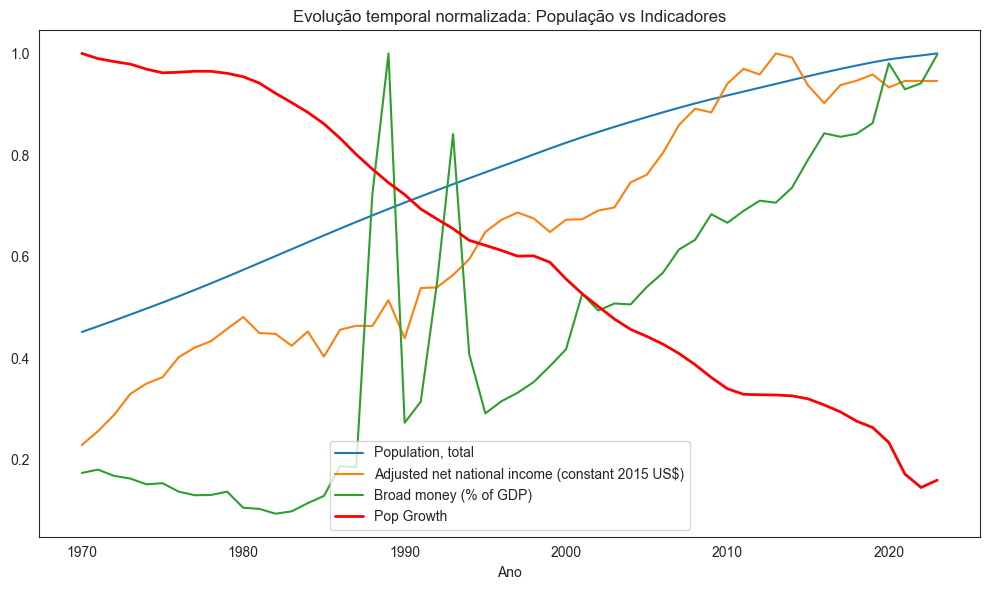

In [62]:
plt.figure(figsize=(10, 6))

# Seleciona as 3 variáveis mais correlacionadas com o crescimento populacional
top_k = new_df_brasil_wide.corr()['Population growth (annual %)'].abs().sort_values(ascending=False)[1:4]

# Normaliza os indicadores pela escala máxima
for var in top_k.index:
    plt.plot(new_df_brasil_wide.index, new_df_brasil_wide[var] / new_df_brasil_wide[var].max(), label=var)

plt.plot(new_df_brasil_wide.index, new_df_brasil_wide['Population growth (annual %)'] / new_df_brasil_wide['Population growth (annual %)'].max(),
         label='Pop Growth', linewidth=2, color='red')

plt.legend()
plt.title("Evolução temporal normalizada: População vs Indicadores")
plt.xlabel("Ano")
plt.tight_layout()
plt.show()



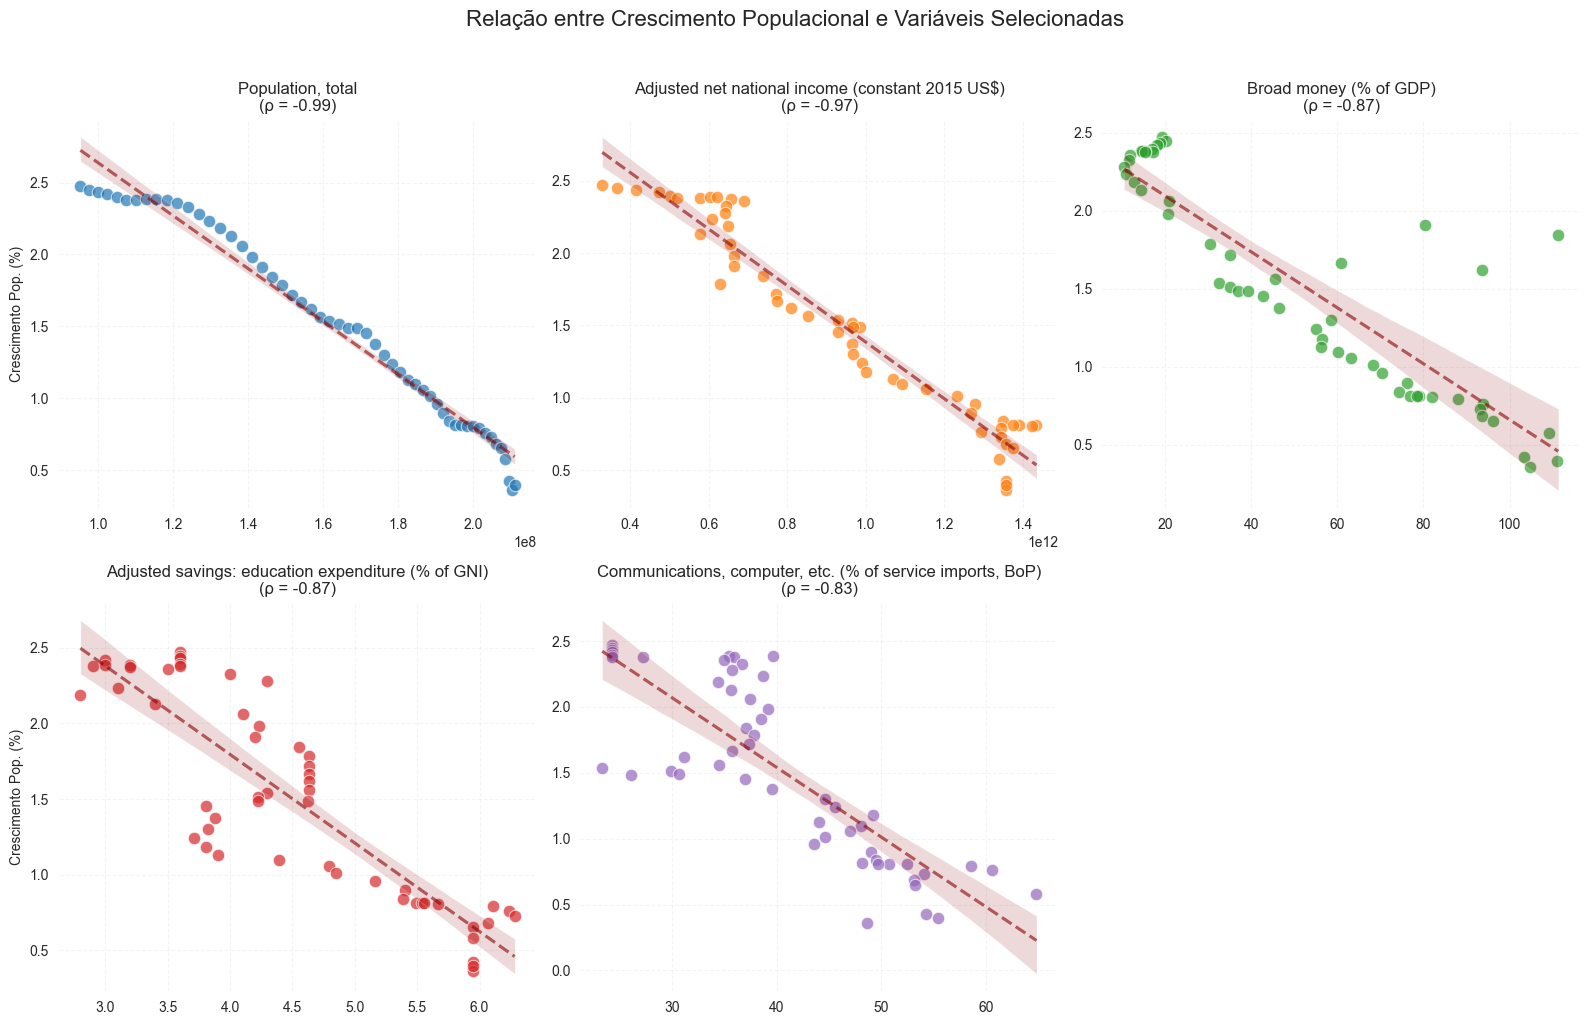

In [63]:
top_k = new_df_brasil_wide.corr()['Population growth (annual %)'].abs().sort_values(ascending=False)[1:6]

# Configurar a figura com subplots
plt.figure(figsize=(16, 10), facecolor='white')
plt.suptitle('Relação entre Crescimento Populacional e Variáveis Selecionadas', y=1.02, fontsize=16)

# Criar um subplot para cada variável
for i, var in enumerate(top_k.index, 1):
    plt.subplot(2, 3, i)  # 2 linhas, 3 colunas

    # Scatterplot
    ax = sns.scatterplot(
        data=new_df_brasil_wide,
        x=var,
        y='Population growth (annual %)',
        color=plt.cm.tab10(i-1),  # Cores diferentes para cada variável
        s=80,
        alpha=0.7
    )

    # Linha de regressão
    sns.regplot(
        data=new_df_brasil_wide,
        x=var,
        y='Population growth (annual %)',
        scatter=False,
        color='darkred',
        line_kws={'linestyle':'--', 'alpha':0.6}
    )

    # Adicionar título e coeficiente de correlação
    corr = new_df_brasil_wide.corr().loc[var, 'Population growth (annual %)']
    plt.title(f'{var}\n(ρ = {corr:.2f})', fontsize=12)
    plt.xlabel('')
    plt.ylabel('Crescimento Pop. (%)' if i == 1 or i == 4 else '', fontsize=10)

    # Grid e estilo
    plt.grid(True, linestyle='--', alpha=0.2)
    sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

## Agrupamentos por PCA

In [64]:
def realizar_pca_macrotemas(dfs_macrotema_unificado):
    """
    Realiza PCA para cada macrotema e gera visualizações.
    
    Args:
        dfs_macrotema_unificado: Dicionário contendo dataframes por macrotema
    """
    # Dicionário para armazenar resultados do PCA
    pca_resultados = {}
    
    # Número máximo de componentes a considerar
    max_componentes = 3
    
    # Para cada macrotema
    for macrotema, df in dfs_macrotema_unificado.items():
        print(f"\n## Analisando macrotema: {macrotema}")
        
        # Interpolar valores faltantes
        df_interpolado = df.interpolate(method='linear', limit_direction='both')
        
        # Verificar se existem dados suficientes
        if df_interpolado.shape[0] < 2 or df_interpolado.shape[1] < 2:
            print(f"Dados insuficientes para o macrotema {macrotema}")
            continue
        
        # Padronização (z-score)
        scaler = StandardScaler()
        df_scaled = pd.DataFrame(
            scaler.fit_transform(df_interpolado),
            index=df_interpolado.index,
            columns=df_interpolado.columns
        )
        
        # Determinar número de componentes
        n_componentes = min(df_scaled.shape[1], max_componentes)
        
        try:
            # Aplicar PCA
            pca = PCA(n_components=n_componentes)
            pca_result = pca.fit_transform(df_scaled)
            
            # Criar DataFrame com resultados
            df_pca = pd.DataFrame(
                pca_result,
                index=df_scaled.index,
                columns=[f'PC{i+1}' for i in range(n_componentes)]
            )
            
            # Armazenar resultados
            pca_resultados[macrotema] = {
                'pca': pca,
                'df_pca': df_pca,
                'variancia_explicada': pca.explained_variance_ratio_,
                'loadings': pd.DataFrame(
                    pca.components_.T,
                    index=df_scaled.columns,
                    columns=[f'PC{i+1}' for i in range(n_componentes)]
                )
            }
            
            print(f"  ✓ PCA realizado com sucesso: {n_componentes} componentes")
            print(f"  ✓ Variância explicada: {pca.explained_variance_ratio_.sum():.2%}")
            
        except Exception as e:
            print(f"Erro ao realizar PCA para {macrotema}: {e}")
    
    return pca_resultados

In [65]:
def plotar_variancias_explicadas(pca_resultados):
    """
    Gera gráficos de barras para a variância explicada por cada componente principal, organizados 3 a 3.
    """
    temas = list(pca_resultados.keys())
    total = len(temas)
    cols = 3
    rows = math.ceil(total / cols)

    fig = make_subplots(
        rows=rows, 
        cols=cols,
        subplot_titles=[f"Variância Explicada - {tema}" for tema in temas],
        vertical_spacing=0.15,
        horizontal_spacing=0.1
    )
    
    cores = px.colors.qualitative.Plotly
    
    for idx, (tema, resultado) in enumerate(pca_resultados.items()):
        row = idx // cols + 1
        col = idx % cols + 1

        variancias = resultado['variancia_explicada']
        variancia_cumulativa = np.cumsum(variancias)
        
        fig.add_trace(
            go.Bar(
                x=[f'PC{j+1}' for j in range(len(variancias))],
                y=variancias * 100,
                name=f"{tema} - Individual",
                marker_color=cores[idx % len(cores)],
                opacity=0.7,
                showlegend=False
            ),
            row=row, col=col
        )
        
        fig.add_trace(
            go.Scatter(
                x=[f'PC{j+1}' for j in range(len(variancias))],
                y=variancia_cumulativa * 100,
                mode='lines+markers',
                name=f"{tema} - Cumulativa",
                marker=dict(color='red'),
                line=dict(width=2),
                showlegend=False
            ),
            row=row, col=col
        )

        fig.add_shape(
            type='line',
            x0=-0.5,
            x1=len(variancias)-0.5,
            y0=75,
            y1=75,
            line=dict(color='green', width=1, dash='dash'),
            row=row, col=col
        )
    
    fig.update_layout(
        height=350 * rows,
        width=1000,
        title_text="Variância Explicada por Componentes Principais",
        showlegend=False
    )
    
    fig.update_yaxes(title_text="Variância Explicada (%)", range=[0, 105])
    fig.update_xaxes(title_text="Componentes Principais")
    
    return fig

In [66]:
resultados_pca = realizar_pca_macrotemas(dfs_macrotema_unificado)

if resultados_pca:
    # Plotar variâncias explicadas
    fig_variancias = plotar_variancias_explicadas(resultados_pca)
    fig_variancias.show()


## Analisando macrotema: Economic Policy & Debt
  ✓ PCA realizado com sucesso: 3 componentes
  ✓ Variância explicada: 45.70%

## Analisando macrotema: Environment
  ✓ PCA realizado com sucesso: 3 componentes
  ✓ Variância explicada: 73.18%

## Analisando macrotema: Financial Sector
  ✓ PCA realizado com sucesso: 3 componentes
  ✓ Variância explicada: 88.80%

## Analisando macrotema: Health
  ✓ PCA realizado com sucesso: 3 componentes
  ✓ Variância explicada: 99.84%

## Analisando macrotema: Private Sector & Trade
  ✓ PCA realizado com sucesso: 3 componentes
  ✓ Variância explicada: 62.16%

## Analisando macrotema: Public Sector
  ✓ PCA realizado com sucesso: 3 componentes
  ✓ Variância explicada: 100.00%

## Analisando macrotema: Social Protection & Labor
Dados insuficientes para o macrotema Social Protection & Labor


In [67]:
from scipy.stats import zscore

# Preencher e padronizar
df = dfs_macrotema_unificado["Economic Policy & Debt"].interpolate(method='linear', limit_direction='both')
df_zscore = df.apply(zscore)
crescimento_zscore = zscore(new_df_brasil_wide['Population growth (annual %)'])

# Função para correlação cruzada
def max_cross_corr(series1, series2, max_lag=5):
    lags = range(-max_lag, max_lag + 1)
    corrs = [series1.corr(series2.shift(lag)) for lag in lags]
    return max(corrs, key=abs)

# Parâmetros
min_corr_com_pop = 0.7  # Remover se a correlação cruzada máxima for menor que isso
max_lag = 5

# Identificar variáveis com fraca relação com o crescimento populacional
variaveis_fracas = []

for col in df_zscore.columns:
    corr = max_cross_corr(df_zscore[col], pd.Series(crescimento_zscore, index=df_zscore.index), max_lag=max_lag)
    if abs(corr) < min_corr_com_pop:
        variaveis_fracas.append(col)

# Remover do DataFrame original
dfs_macrotema_unificado["Economic Policy & Debt"] = df.drop(columns=variaveis_fracas)

print(f"\n{len(variaveis_fracas)} variáveis removidas por fraca correlação cruzada com o crescimento populacional.")



66 variáveis removidas por fraca correlação cruzada com o crescimento populacional.


In [68]:
from scipy.stats import zscore

# Preencher e padronizar
df = dfs_macrotema_unificado["Private Sector & Trade"].interpolate(method='linear', limit_direction='both')
df_zscore = df.apply(zscore)
crescimento_zscore = zscore(new_df_brasil_wide['Population growth (annual %)'])

# Função para correlação cruzada
def max_cross_corr(series1, series2, max_lag=5):
    lags = range(-max_lag, max_lag + 1)
    corrs = [series1.corr(series2.shift(lag)) for lag in lags]
    return max(corrs, key=abs)

# Parâmetros
min_corr_com_pop = 0.7  # Remover se a correlação cruzada máxima for menor que isso
max_lag = 5

# Identificar variáveis com fraca relação com o crescimento populacional
variaveis_fracas = []

for col in df_zscore.columns:
    corr = max_cross_corr(df_zscore[col], pd.Series(crescimento_zscore, index=df_zscore.index), max_lag=max_lag)
    if abs(corr) < min_corr_com_pop:
        variaveis_fracas.append(col)

# Remover do DataFrame original
dfs_macrotema_unificado["Private Sector & Trade"] = df.drop(columns=variaveis_fracas)

print(f"\n{len(variaveis_fracas)} variáveis removidas por fraca correlação cruzada com o crescimento populacional.")


13 variáveis removidas por fraca correlação cruzada com o crescimento populacional.


In [69]:
resultados_pca = realizar_pca_macrotemas(dfs_macrotema_unificado)

if resultados_pca:
    # Plotar variâncias explicadas
    fig_variancias = plotar_variancias_explicadas(resultados_pca)
    fig_variancias.show()


## Analisando macrotema: Economic Policy & Debt
  ✓ PCA realizado com sucesso: 3 componentes
  ✓ Variância explicada: 78.71%

## Analisando macrotema: Environment
  ✓ PCA realizado com sucesso: 3 componentes
  ✓ Variância explicada: 73.18%

## Analisando macrotema: Financial Sector
  ✓ PCA realizado com sucesso: 3 componentes
  ✓ Variância explicada: 88.80%

## Analisando macrotema: Health
  ✓ PCA realizado com sucesso: 3 componentes
  ✓ Variância explicada: 99.84%

## Analisando macrotema: Private Sector & Trade
  ✓ PCA realizado com sucesso: 3 componentes
  ✓ Variância explicada: 85.25%

## Analisando macrotema: Public Sector
  ✓ PCA realizado com sucesso: 3 componentes
  ✓ Variância explicada: 100.00%

## Analisando macrotema: Social Protection & Labor
Dados insuficientes para o macrotema Social Protection & Labor


# Modelagem Curva de Crescimento

In [70]:
import numpy as np
from scipy.optimize import curve_fit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib import cm
import warnings
warnings.filterwarnings("ignore")

In [71]:
# 1) Carregar e preparar os dados
# Anos serão deslocados para melhorar a convergência
anos_originais = new_df_brasil_wide.index.values.astype(float)
anos = anos_originais - anos_originais.min()  # Ajustar para iniciar em 0
pop = new_df_brasil_wide['Population, total'].values.astype(float) / 1e6  # Escala em milhões

# 2) Definir funções de crescimento populacional
def logistic(t, K, r, t0):
    """Modelo logístico (Verhulst): crescimento com capacidade de suporte."""
    return K / (1 + np.exp(-r * (t - t0)))

def gompertz(t, K, b, r):
    """Modelo de Gompertz: crescimento assimétrico."""
    return K * np.exp(-b * np.exp(-r * t))

def richards(t, K, r, t0, v):
    """Modelo de Richards: logístico generalizado com ponto de inflexão variável."""
    return K / (1 + v * np.exp(-r * (t - t0)))**(1/v)

def bertalanffy(t, K, r, t0):
    """Modelo de von Bertalanffy: crescimento com taxa decrescente."""
    return K * (1 - np.exp(-r * (t - t0)))**3

def weibull(t, K, k, lam):
    """Modelo de Weibull: crescimento com taxa variável."""
    # Adicionamos um pequeno valor para evitar divisão por zero
    return K * (1 - np.exp(-(t/lam)**k))

def brody(t, K, B, k):
    """Modelo de Brody: crescimento exponencial modificado."""
    return K * (1 - B * np.exp(-k * t))

def exponential(t, a, b):
    """Modelo de crescimento exponencial."""
    return a * np.exp(b * t)

In [72]:
# 3) Preparar modelos para teste
models = {
    'Logístico': (logistic, 3, [max(pop)*1.2, 0.05, np.median(anos)]),
    'Gompertz': (gompertz, 3, [max(pop)*1.2, 2.0, 0.05]),
    'Richards': (richards, 4, [max(pop)*1.2, 0.05, np.median(anos), 1.0]),
    'Bertalanffy': (bertalanffy, 3, [max(pop)*1.2, 0.05, min(anos)]),
    'Weibull': (weibull, 3, [max(pop)*1.2, 2.0, np.median(anos)]),
    'Brody': (brody, 3, [max(pop)*1.2, 1.0, 0.05]),
    'Exponencial': (exponential, 2, [pop[0], 0.02])
}

# Configuração para validação cruzada histórica
n_validacao = 10  # Usar os últimos 10 anos para validação
anos_treino = anos[:-n_validacao]
pop_treino = pop[:-n_validacao]
anos_teste = anos[-n_validacao:]
pop_teste = pop[-n_validacao:]


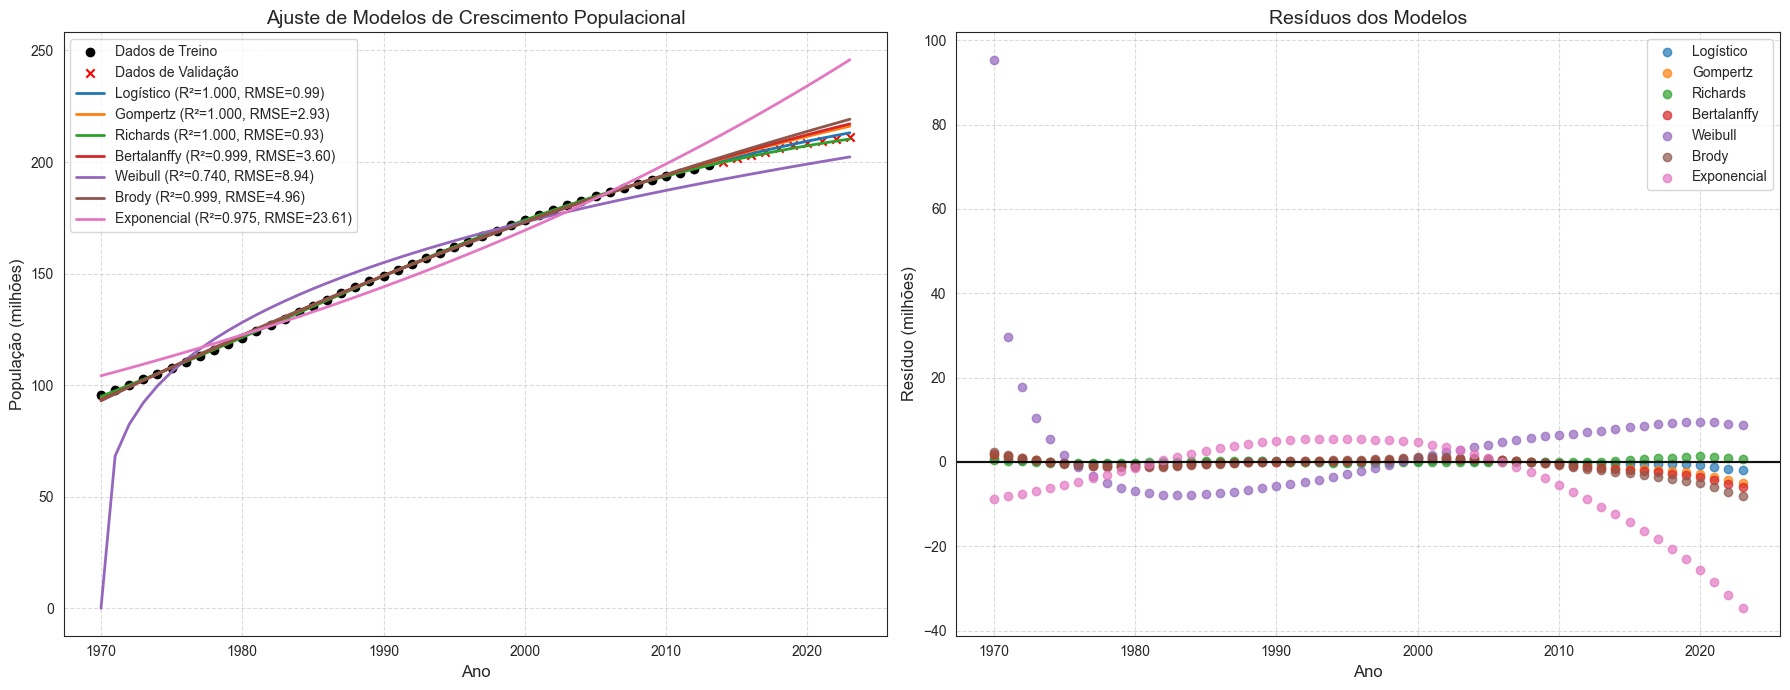


Comparação de Modelos:


,RMSE (treino),RMSE (teste),R² (treino),R² (teste),AIC,BIC
Modelo,,,,,,
Logístico,0.3510,0.9854,0.9999,0.9248,-84.12,-76.98
Gompertz,0.6314,2.9251,0.9996,0.3370,-32.47,-25.33
Richards,0.1957,0.9328,1.0000,0.9326,-133.56,-124.64
Bertalanffy,0.7330,3.5986,0.9995,-0.0035,-19.34,-12.20
Weibull,16.1800,8.9379,0.7396,-5.1903,252.97,260.11
Brody,0.9426,4.9642,0.9991,-0.9096,2.80,9.94
Exponencial,4.9721,23.6093,0.9754,-42.1923,147.14,152.49


In [73]:
# 4) Ajustar modelos e calcular métricas
results = []
cor_cycle = cm.tab10.colors

# Figura para comparação dos ajustes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Plotar dados reais (treino e validação)
anos_originais_treino = anos_originais[:-n_validacao]
anos_originais_teste = anos_originais[-n_validacao:]
ax1.scatter(anos_originais_treino, pop_treino, color='black', label='Dados de Treino')
ax1.scatter(anos_originais_teste, pop_teste, color='red', marker='x', label='Dados de Validação')

# Ajuste dos modelos
pcovs = {}
for i, (name, (func, k, p0)) in enumerate(models.items()):
    try:
        # Ajuste do modelo com dados de treino
        params, pcov = curve_fit(func, anos_treino, pop_treino, p0=p0, maxfev=50000, bounds=(-np.inf, np.inf))
        pcovs[name] = pcov  # salva a matriz de covariância real

        # Calcular valores ajustados
        fitted_treino = func(anos_treino, *params)
        fitted_teste = func(anos_teste, *params)
        fitted_todos = func(anos, *params)
        
        # Métricas de treino
        rmse_treino = np.sqrt(mean_squared_error(pop_treino, fitted_treino))
        r2_treino = r2_score(pop_treino, fitted_treino)
        mae_treino = mean_absolute_error(pop_treino, fitted_treino)
        
        # Métricas de teste (validação)
        rmse_teste = np.sqrt(mean_squared_error(pop_teste, fitted_teste))
        r2_teste = r2_score(pop_teste, fitted_teste)
        mae_teste = mean_absolute_error(pop_teste, fitted_teste)
        
        # Critérios de informação
        n = len(pop_treino)
        sse = np.sum((pop_treino - fitted_treino)**2)
        aic = n * np.log(sse/n) + 2 * (k + 1)  # k parâmetros + 1 para variância
        bic = n * np.log(sse/n) + (k + 1) * np.log(n)
        
        # Calcular intervalos de confiança para os parâmetros
        perr = np.sqrt(np.diag(pcov))
        params_ci = [(p - 1.96*e, p + 1.96*e) for p, e in zip(params, perr)]
        
        results.append({
            'Modelo': name,
            'Parâmetros': np.round(params, 4).tolist(),
            'IC 95%': np.round(params_ci, 4).tolist(),
            'RMSE (treino)': round(rmse_treino, 4),
            'RMSE (teste)': round(rmse_teste, 4),
            'MAE (treino)': round(mae_treino, 4),
            'MAE (teste)': round(mae_teste, 4),
            'R² (treino)': round(r2_treino, 4),
            'R² (teste)': round(r2_teste, 4),
            'AIC': round(aic, 2),
            'BIC': round(bic, 2)
        })
        
        # Plotar curva ajustada (gráfico 1)
        cor = cor_cycle[i % len(cor_cycle)]
        ax1.plot(anos_originais, fitted_todos, color=cor, 
                 label=f'{name} (R²={r2_treino:.3f}, RMSE={rmse_teste:.2f})', 
                 linewidth=2)
        
        # Plotar resíduos (gráfico 2)
        residuos = pop - fitted_todos
        ax2.scatter(anos_originais, residuos, color=cor, alpha=0.7, label=name)
        ax2.axhline(y=0, color='black', linestyle='-', alpha=0.3)
        
    except Exception as e:
        print(f"Erro no modelo {name}: {e}")

# Configurar gráfico de ajuste
ax1.set_title('Ajuste de Modelos de Crescimento Populacional', fontsize=14)
ax1.set_xlabel('Ano', fontsize=12)
ax1.set_ylabel('População (milhões)', fontsize=12)
ax1.legend(fontsize=10)
ax1.grid(True, linestyle='--', alpha=0.7)

# Configurar gráfico de resíduos
ax2.set_title('Resíduos dos Modelos', fontsize=14)
ax2.set_xlabel('Ano', fontsize=12)
ax2.set_ylabel('Resíduo (milhões)', fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Exibir resultados em formato tabular
df_results = pd.DataFrame(results).set_index('Modelo')
print("\nComparação de Modelos:")
display(df_results[['RMSE (treino)', 'RMSE (teste)', 'R² (treino)', 'R² (teste)', 'AIC', 'BIC']])


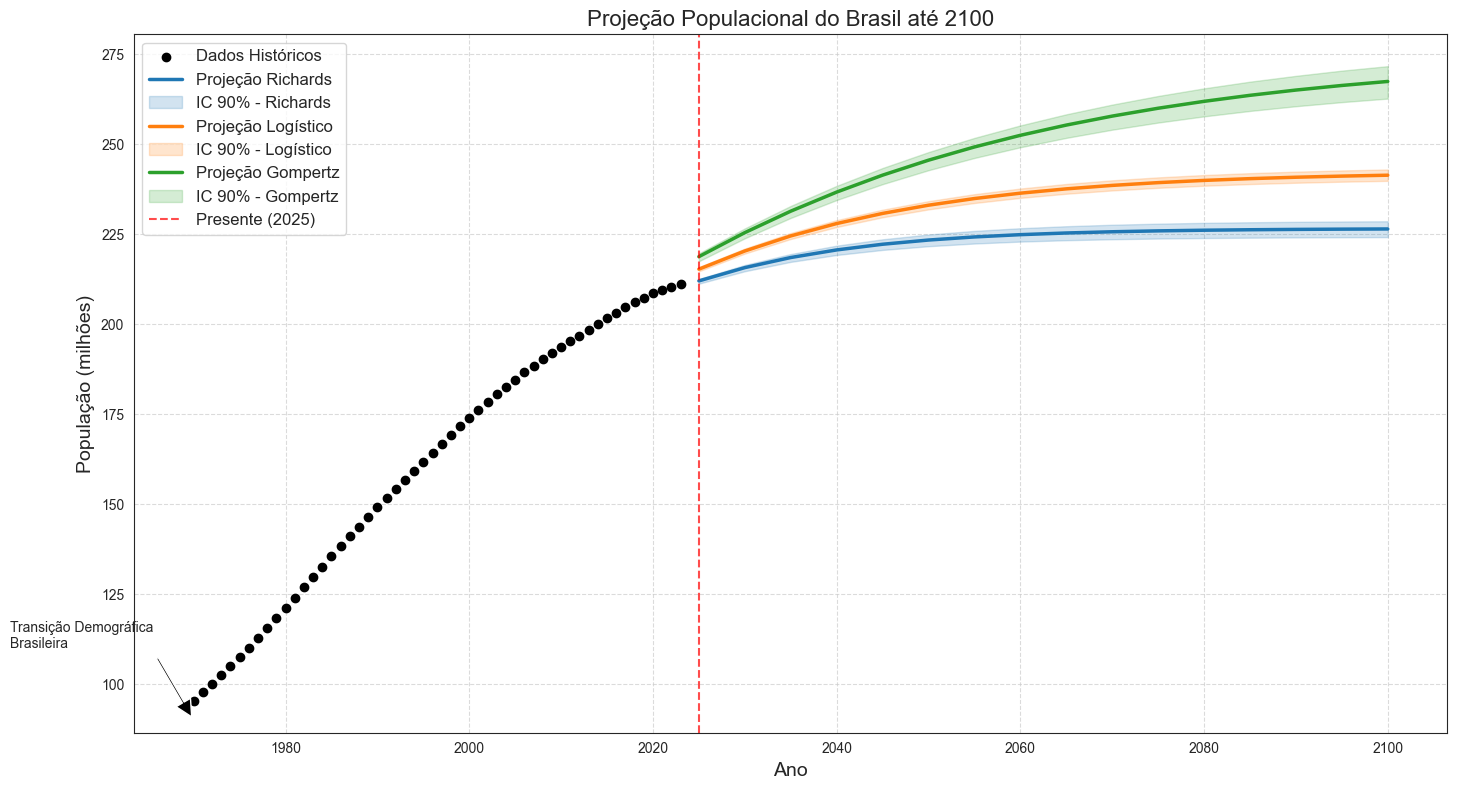

In [74]:
# 5) Projeção futura (2025 a 2100)
# Calcular anos futuros na escala deslocada
anos_futuros_originais = np.arange(2025, 2101, 5)
anos_futuros = anos_futuros_originais - anos_originais.min()

# Selecionar os 3 melhores modelos baseado no RMSE de teste
df_sorted = df_results.sort_values('RMSE (teste)')
top_models = df_sorted.index[:3].tolist()

plt.figure(figsize=(14, 8))

# Plotar dados históricos
plt.scatter(anos_originais, pop, color='black', label='Dados Históricos')

cores = ['#1f77b4', '#ff7f0e', '#2ca02c']

# Projeções dos melhores modelos
for i, model_name in enumerate(top_models):
    func = models[model_name][0]
    params = df_results.loc[model_name, 'Parâmetros']
    
    # Calcular projeção
    projecao = func(anos_futuros, *params)
    
    # Calcular intervalos de confiança por simulação de Monte Carlo
    n_sim = 1000
    projections_sim = np.zeros((n_sim, len(anos_futuros)))
    
    # Obter covariância e parâmetros
# Obter covariância real do modelo ajustado
    pcov = pcovs[model_name]
    params_mean = np.array(params)
    
    # Simular parâmetros
    params_sim = np.random.multivariate_normal(params_mean, pcov, size=n_sim)
    
    # Calcular projeções para cada conjunto de parâmetros
    for j in range(n_sim):
        try:
            projections_sim[j, :] = func(anos_futuros, *params_sim[j, :])
        except:
            projections_sim[j, :] = projecao  # fallback para parâmetros que causam erro
    
    # Calcular intervalos de confiança (percentis 5% e 95%)
    lower_bound = np.percentile(projections_sim, 5, axis=0)
    upper_bound = np.percentile(projections_sim, 95, axis=0)
    
    # Plotar projeção e intervalo de confiança
    plt.plot(anos_futuros_originais, projecao, '-', color=cores[i], 
             linewidth=2.5, label=f'Projeção {model_name}')
    plt.fill_between(anos_futuros_originais, lower_bound, upper_bound, 
                      color=cores[i], alpha=0.2, label=f'IC 90% - {model_name}')

# Configurar gráfico
plt.title('Projeção Populacional do Brasil até 2100', fontsize=16)
plt.xlabel('Ano', fontsize=14)
plt.ylabel('População (milhões)', fontsize=14)
plt.axvline(x=2025, color='red', linestyle='--', alpha=0.7, label='Presente (2025)')
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# Adicionar anotações para eventos históricos relevantes
plt.annotate('Transição Demográfica\nBrasileira', xy=(1970, 90), xytext=(1950, 110),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1.5), fontsize=10)

plt.show()


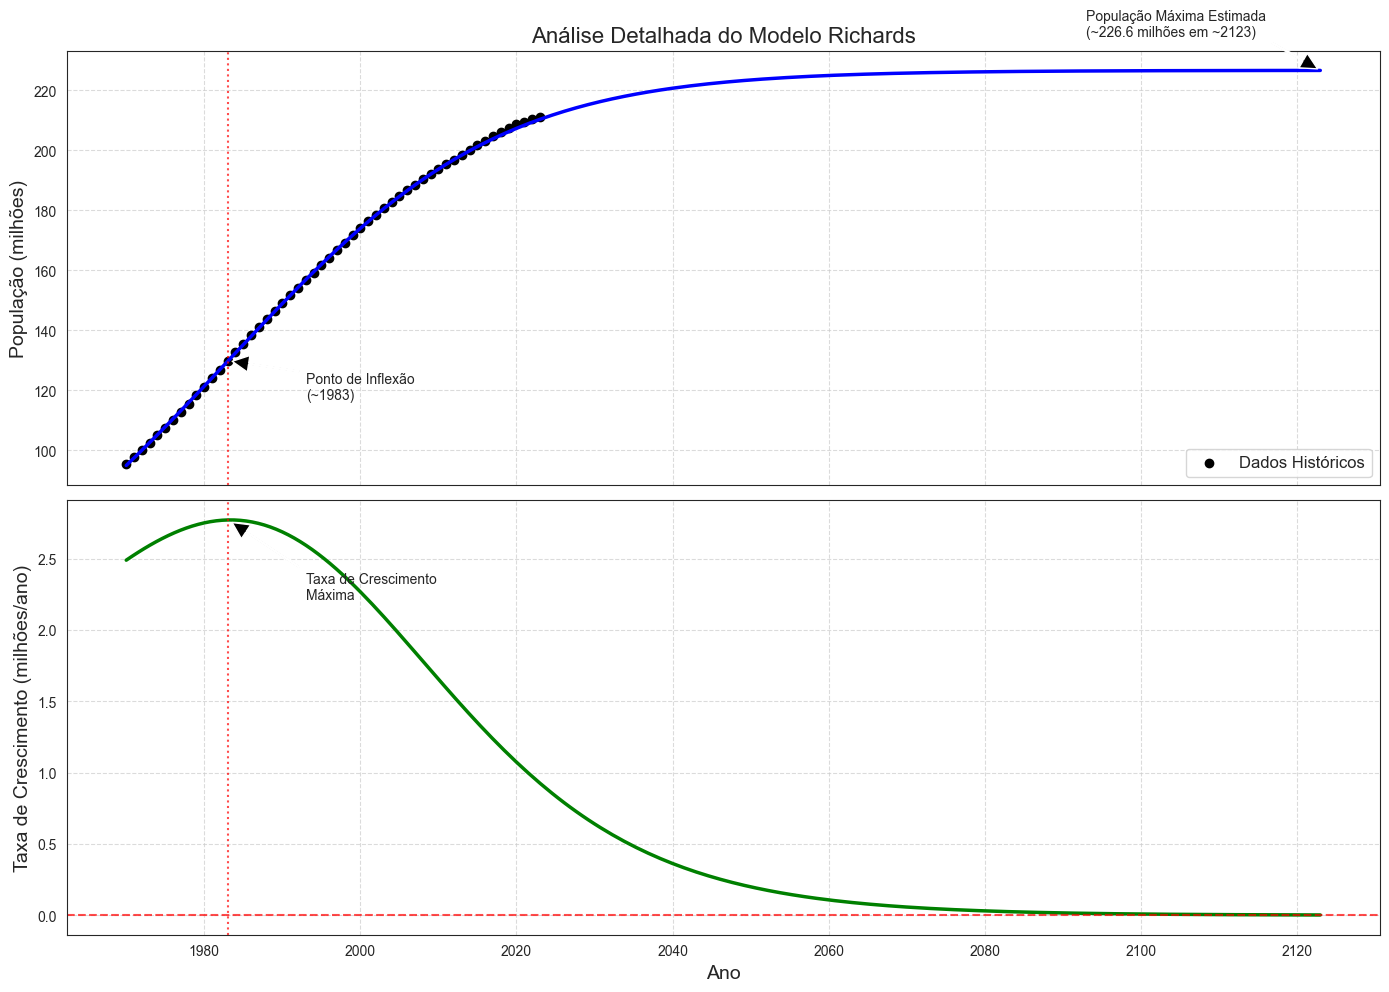

In [75]:
# 6) Análise detalhada do melhor modelo
best_model_name = top_models[0]
best_model_func = models[best_model_name][0]
best_params = df_results.loc[best_model_name, 'Parâmetros']

# Calcular taxa de crescimento implícita (derivada)
def growth_rate(func, params, t):
    """Calcula taxa de crescimento instantânea por diferença finita."""
    dt = 0.1
    p1 = func(t+dt, *params)
    p2 = func(t, *params)
    return (p1 - p2) / dt

# Gerar anos para análise detalhada
anos_detalhados = np.linspace(anos.min(), anos.max() + 100, 200)
anos_detalhados_originais = anos_detalhados + anos_originais.min()

# Calcular população e taxa de crescimento
pop_prevista = best_model_func(anos_detalhados, *best_params)
taxa_crescimento = [growth_rate(best_model_func, best_params, t) for t in anos_detalhados]

# Plotar
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# População
ax1.plot(anos_detalhados_originais, pop_prevista, 'b-', linewidth=2.5)
ax1.scatter(anos_originais, pop, color='black', label='Dados Históricos')
ax1.set_title(f'Análise Detalhada do Modelo {best_model_name}', fontsize=16)
ax1.set_ylabel('População (milhões)', fontsize=14)
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend(fontsize=12)

# Taxa de crescimento
ax2.plot(anos_detalhados_originais, taxa_crescimento, 'g-', linewidth=2.5)
ax2.set_xlabel('Ano', fontsize=14)
ax2.set_ylabel('Taxa de Crescimento (milhões/ano)', fontsize=14)
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.axhline(y=0, color='red', linestyle='--', alpha=0.7)

# Estimar ponto de inflexão e capacidade de suporte
inflexao_idx = np.argmax(taxa_crescimento)
ano_inflexao = anos_detalhados_originais[inflexao_idx]
pico_pop = np.max(pop_prevista)
ano_pico = anos_detalhados_originais[np.argmax(pop_prevista)]

# Anotações
ax1.axvline(x=ano_inflexao, color='red', linestyle=':', alpha=0.7)
ax1.annotate(f'Ponto de Inflexão\n(~{int(ano_inflexao)})', 
            xy=(ano_inflexao, best_model_func(anos_detalhados[inflexao_idx], *best_params)),
            xytext=(ano_inflexao+10, best_model_func(anos_detalhados[inflexao_idx], *best_params)*0.9),
            arrowprops=dict(facecolor='black', shrink=0.05, width=1),
            fontsize=10)

ax1.annotate(f'População Máxima Estimada\n(~{pico_pop:.1f} milhões em ~{int(ano_pico)})', 
            xy=(ano_pico, pico_pop),
            xytext=(ano_pico-30, pico_pop*1.05),
            arrowprops=dict(facecolor='black', shrink=0.05, width=1),
            fontsize=10)

ax2.axvline(x=ano_inflexao, color='red', linestyle=':', alpha=0.7)
ax2.annotate('Taxa de Crescimento\nMáxima', 
            xy=(ano_inflexao, np.max(taxa_crescimento)),
            xytext=(ano_inflexao+10, np.max(taxa_crescimento)*0.8),
            arrowprops=dict(facecolor='black', shrink=0.05, width=1),
            fontsize=10)

plt.tight_layout()
plt.show()

In [76]:
# 7) Tabela com projeções específicas dos melhores modelos
anos_especificos = [2025, 2030, 2040, 2050, 2075, 2100]
anos_especificos_shifted = np.array(anos_especificos) - anos_originais.min()

projecoes = {}
for model_name in top_models:
    func = models[model_name][0]
    params = df_results.loc[model_name, 'Parâmetros']
    projecoes[model_name] = [func(ano, *params) for ano in anos_especificos_shifted]

# Adicionar dados ao DataFrame
df_projecoes = pd.DataFrame(projecoes, index=anos_especificos)
df_projecoes.index.name = 'Ano'
df_projecoes.columns.name = 'Modelo'

print("\nProjeções de População do Brasil (milhões):")
display(df_projecoes.round(2))



Projeções de População do Brasil (milhões):


Modelo,Richards,Logístico,Gompertz
Ano,,,
2025,212.08,215.34,218.82
2030,215.77,220.39,225.49
2040,220.69,228.02,236.76
2050,223.43,233.11,245.62
2075,225.98,239.38,260.05
2100,226.51,241.44,267.49


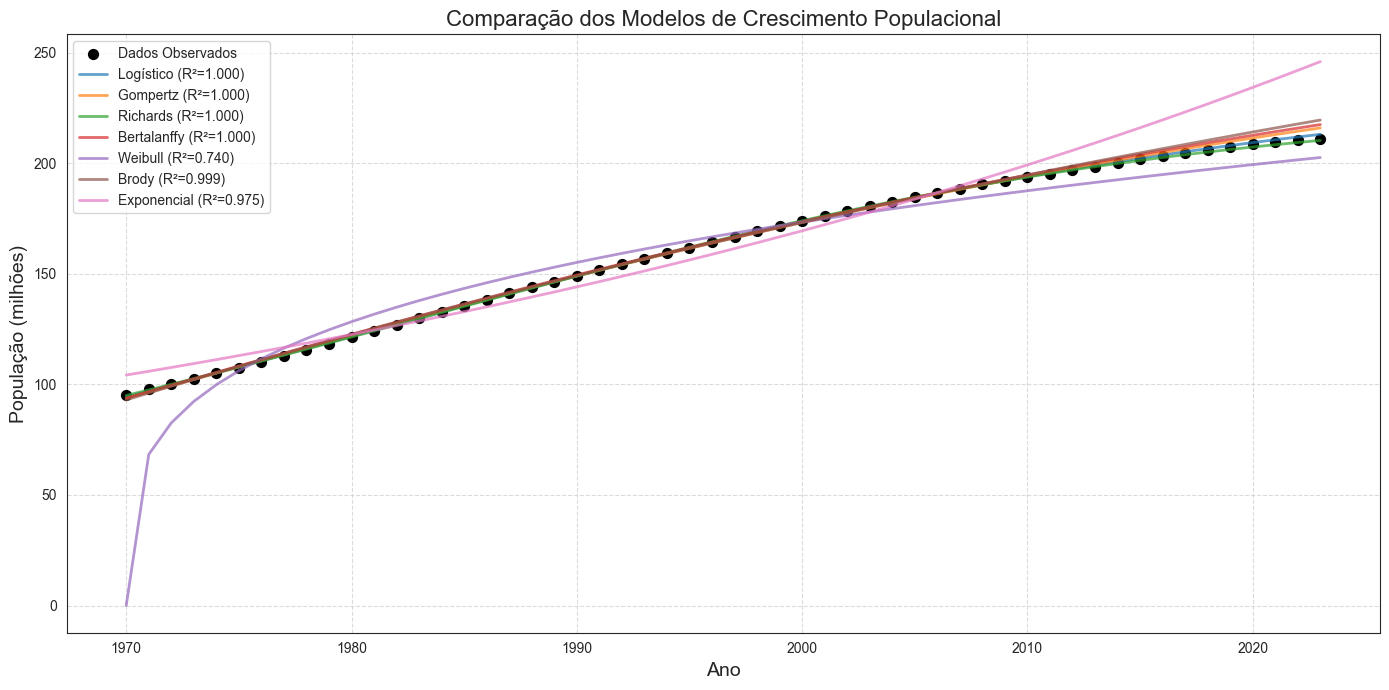

In [77]:
# 8) Comparação visual dos modelos com dados observados
plt.figure(figsize=(14, 7))

# Plotar dados reais
plt.scatter(anos_originais, pop, color='black', s=50, label='Dados Observados')

# Plotar curvas ajustadas de todos os modelos
for i, (name, (func, _, _)) in enumerate(models.items()):
    if name in df_results.index:
        params = df_results.loc[name, 'Parâmetros']
        fitted = func(anos, *params)
        plt.plot(anos_originais, fitted, '-', linewidth=2, alpha=0.7,
                 label=f'{name} (R²={df_results.loc[name, "R² (treino)"]:.3f})')

plt.title('Comparação dos Modelos de Crescimento Populacional', fontsize=16)
plt.xlabel('Ano', fontsize=14)
plt.ylabel('População (milhões)', fontsize=14)
plt.legend(fontsize=10, loc='best')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Modelo de Richard com indicadores


In [78]:
import numpy as np
from scipy.optimize import curve_fit, differential_evolution
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
import pandas as pd

In [79]:
# Definindo a função de Richards
def modelo_richards(t, K, r, v, t0):
    """
    Modelo de Richards: logístico generalizado com ponto de inflexão variável.
    
    Parâmetros:
    - t: tempo (variável independente)
    - K: capacidade de suporte / valor assintótico
    - r: taxa de crescimento
    - v: relacionado com o ponto de inflexão (v>0)
    - t0: tempo do ponto médio
    
    Retorno:
    - Valor da população no tempo t
    """
    return K / (1 + v * np.exp(-r * (t - t0)))**(1/v)

# Definindo uma versão da função de Richards que incluirá indicadores como parâmetros
def modelo_richards_com_indicadores(t, K_base, K_coef, r_base, r_coef, v_base, v_coef, t0_base, t0_coef, *indicadores_args):
    """
    Modelo de Richards com parâmetros influenciados por indicadores econômicos.
    
    Cada parâmetro da curva de Richards (K, r, v, t0) é influenciado por um conjunto de indicadores:
    param = param_base + param_coef * (indicador_1 + indicador_2 + ...)
    
    Parâmetros:
    - t: tempo (anos)
    - K_base, r_base, v_base, t0_base: parâmetros base
    - K_coef, r_coef, v_coef, t0_coef: coeficientes de influência dos indicadores
    - indicadores_args: valores dos indicadores para cada ano (flatten)
    
    Retorno:
    - População estimada
    """
    # Reconstruindo o array de indicadores
    num_indicadores = len(indicadores_args) // len(t)
    indicators = np.array(indicadores_args).reshape(num_indicadores, len(t)).T
    
    # Calculando os parâmetros influenciados pelos indicadores
    K = K_base + K_coef * np.sum(indicators, axis=1)
    r = r_base + r_coef * np.sum(indicators, axis=1)
    v = v_base + v_coef * np.sum(indicators, axis=1)
    t0 = t0_base + t0_coef * np.sum(indicators, axis=1)
    
    # Aplicando limites para garantir valores válidos
    K = np.maximum(K, 1e5)  # População mínima
    r = np.clip(r, 0.001, 1.0)  # Taxa de crescimento positiva e limitada
    v = np.maximum(v, 0.001)  # v deve ser positivo
    
    # Calculando o modelo para cada ponto no tempo
    pop = np.zeros_like(t, dtype=float)
    for i in range(len(t)):
        pop[i] = modelo_richards(t[i], K[i], r[i], v[i], t0[i])
    
    return pop

# Função para preparar os dados para modelagem
# %%
# Função para preparar os dados para modelagem
def preparar_dados_para_modelagem(df, indicadores_selecionados_lista):
    """
    Prepara os dados para a modelagem com a curva de Richards.

    Parâmetros:
    - df: DataFrame com os dados
    - indicadores_selecionados_lista: lista de nomes de indicadores a serem potencialmente usados como features.

    Retorno:
    - X: array com anos (normalizado, começando em 0)
    - y: array com valores de população (1D)
    - indicators_scaled: array 2D com indicadores normalizados (features para o modelo com indicadores).
                       Shape: (n_observacoes, n_features_indicadores)
    - feature_indicator_names: lista dos nomes dos indicadores que estão em indicators_scaled.
    """
    # Validar os nomes dos indicadores selecionados para features
    valid_feature_names_from_selection = [ind for ind in indicadores_selecionados_lista if ind in df.columns and ind != 'Population, total']

    # Colunas necessárias para alinhamento e remoção de NaNs: 'Population, total' e os indicadores de features válidos.
    # Usar dict.fromkeys para garantir unicidade e preservar a ordem (para Python 3.7+)
    cols_for_alignment = list(dict.fromkeys(['Population, total'] + valid_feature_names_from_selection))

    # Criar DataFrame alinhado e remover NaNs
    df_aligned = df[cols_for_alignment].dropna()

    if df_aligned.empty:
        raise ValueError("DataFrame vazio após remover NaNs com as colunas selecionadas. Verifique os dados de entrada.")

    # Preparar X (tempo) e y (população)
    anos = df_aligned.index.values
    X = anos - anos.min()  # Normaliza os anos para começar em 0
    y = df_aligned['Population, total'].values  # y agora é garantidamente 1D

    # Preparar os indicadores (features)
    if valid_feature_names_from_selection:
        indicators_data = df_aligned[valid_feature_names_from_selection].values
        scaler = StandardScaler()
        indicators_scaled = scaler.fit_transform(indicators_data)
    else:
        # Se não houver indicadores de features válidos, criar um array 2D vazio
        indicators_scaled = np.empty((len(y), 0))

    # Os nomes retornados como 'indicadores_validos' na chamada original agora são 'feature_indicator_names'
    return X, y, indicators_scaled, valid_feature_names_from_selection

# Função para ajustar o modelo básico de Richards
def ajustar_modelo_richards_basico(X, y):
    """
    Ajuste do modelo básico de Richards (sem indicadores).
    
    Parâmetros:
    - X: anos
    - y: população
    
    Retorno:
    - params: parâmetros ajustados [K, r, v, t0]
    - y_pred: valores preditos
    """
    # Estimativas iniciais
    p0 = [
        y.max() * 1.2,  # K: um pouco maior que a população máxima
        0.03,           # r: taxa de crescimento moderada
        0.5,            # v: valor típico
        X.mean()        # t0: ponto médio do período
    ]
    
    # Limites para os parâmetros
    bounds = [
        (y.max(), y.max() * 5),  # K
        (0.001, 0.5),            # r
        (0.001, 10),             # v
        (0, X.max())             # t0
    ]
    
    try:
        # Tentativa com curve_fit
        params, _ = curve_fit(
            modelo_richards, X, y, 
            p0=p0, 
            bounds=([b[0] for b in bounds], [b[1] for b in bounds]),
            method='trf',
            maxfev=10000
        )
    except:
        # Se falhar, tenta com otimização global
        def obj_func(params):
            y_pred = modelo_richards(X, *params)
            return np.sum((y - y_pred)**2)
        
        result = differential_evolution(
            obj_func, 
            bounds,
            maxiter=1000, 
            popsize=20,
            tol=1e-8
        )
        params = result.x
    
    # Calcular valores preditos
    y_pred = modelo_richards(X, *params)
    
    return params, y_pred

# Função para ajustar o modelo de Richards com indicadores
def ajustar_modelo_richards_com_indicadores(X, y, indicators):
    """
    Ajuste do modelo de Richards com indicadores.
    
    Parâmetros:
    - X: anos
    - y: população
    - indicators: matriz de indicadores [n_amostras, n_indicadores]
    
    Retorno:
    - params: parâmetros ajustados
    - y_pred: valores preditos
    """
    # Planificar a matriz de indicadores para passar como argumentos
    indicators_flat = indicators.T.flatten()
    
    # Criar a função wrapper para ajuste
    def modelo_wrapper(t, K_base, K_coef, r_base, r_coef, v_base, v_coef, t0_base, t0_coef):
        return modelo_richards_com_indicadores(
            t, K_base, K_coef, r_base, r_coef, v_base, v_coef, t0_base, t0_coef,
            *indicators_flat
        )
    
    # Estimativas iniciais
    p0 = [
        y.max() * 0.8,  # K_base
        0.1,            # K_coef
        0.02,           # r_base
        0.001,          # r_coef
        0.5,            # v_base
        0.01,           # v_coef
        X.mean(),       # t0_base
        0.1             # t0_coef
    ]
    
    # Ajuste do modelo
    try:
        params, _ = curve_fit(
            modelo_wrapper, X, y, 
            p0=p0,
            method='trf',
            maxfev=10000,
            bounds=(
                [y.max()*0.5, -1.0, 0.001, -0.1, 0.001, -0.1, 0, -1],
                [y.max()*2.0, 1.0, 0.1, 0.1, 10, 0.1, X.max(), 1]
            )
        )
    except Exception as e:
        print(f"Erro no ajuste: {e}")
        # Usar valores iniciais como fallback
        params = p0
    
    # Calcular valores preditos
    y_pred = modelo_wrapper(X, *params)
    
    return params, y_pred

# Função para avaliar modelo
def avaliar_modelo(y_true, y_pred, nome_modelo):
    """
    Avalia a qualidade do modelo comparando valores reais e preditos.
    
    Parâmetros:
    - y_true: valores reais
    - y_pred: valores preditos
    - nome_modelo: nome do modelo para exibição
    """
    # Métricas de avaliação
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    print(f"\nAvaliação do modelo {nome_modelo}:")
    print(f"MSE: {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R²: {r2:.4f}")
    
    return {"MSE": mse, "RMSE": rmse, "R2": r2}

# Função para plotar os resultados
def plotar_resultados(X, y, y_pred_basico, y_pred_com_indicadores, anos_reais):
    """
    Plota os resultados dos modelos.
    
    Parâmetros:
    - X: anos normalizados
    - y: população real
    - y_pred_basico: previsões do modelo básico
    - y_pred_com_indicadores: previsões do modelo com indicadores
    - anos_reais: anos originais (não normalizados)
    """
    plt.figure(figsize=(12, 8))
    
    # Plotar dados reais
    plt.scatter(anos_reais, y, color='black', label='População Real', alpha=0.7)
    
    # Plotar modelo básico
    plt.plot(anos_reais, y_pred_basico, 'b-', linewidth=2, label='Modelo de Richards Básico')
    
    # Plotar modelo com indicadores
    plt.plot(anos_reais, y_pred_com_indicadores, 'r-', linewidth=2, label='Modelo de Richards com Indicadores')
    
    # Adicionar legenda e rótulos
    plt.title('Modelagem de População do Brasil com Curva de Richards', fontsize=16)
    plt.xlabel('Ano', fontsize=14)
    plt.ylabel('População', fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(fontsize=12)
    
    # Formatar eixo Y em milhões
    plt.ticklabel_format(axis='y', style='plain')
    
    plt.tight_layout()
    plt.show()

# Função para plotar a importância dos indicadores
def plotar_importancia_indicadores(params, indicadores_nomes):
    """
    Plota a importância relativa dos indicadores no modelo.
    
    Parâmetros:
    - params: parâmetros do modelo [K_base, K_coef, r_base, r_coef, v_base, v_coef, t0_base, t0_coef]
    - indicadores_nomes: nomes dos indicadores
    """
    # Extrair coeficientes
    impactos = [abs(params[1]), abs(params[3]), abs(params[5]), abs(params[7])]
    parametros = ['Capacidade (K)', 'Taxa de Crescimento (r)', 'Forma (v)', 'Ponto Médio (t0)']
    
    plt.figure(figsize=(10, 6))
    
    # Criar barras para cada parâmetro
    x = np.arange(len(parametros))
    plt.bar(x, impactos, color=['blue', 'green', 'orange', 'red'])
    
    # Adicionar rótulos e título
    plt.xlabel('Parâmetro da Curva de Richards')
    plt.ylabel('Importância Relativa (valor absoluto do coeficiente)')
    plt.title('Impacto dos Indicadores nos Parâmetros do Modelo')
    plt.xticks(x, parametros)
    
    plt.tight_layout()
    plt.show()
    
    # Imprimir informações adicionais
    print("\nInterpretação do impacto dos indicadores:")
    print(f"Os indicadores {', '.join(indicadores_nomes)} têm maior impacto em:")
    
    # Encontrar parâmetro mais impactado
    idx_max = np.argmax(impactos)
    print(f"- {parametros[idx_max]} (coeficiente = {impactos[idx_max]:.4f})")
    
    # Classificar os parâmetros pelo impacto
    ordem = np.argsort(impactos)[::-1]
    for i in ordem[1:]:
        print(f"- {parametros[i]} (coeficiente = {impactos[i]:.4f})")

# Função para projeção futura
def projetar_populacao_futura(params_basico, params_indicadores, X, indicators, anos_reais, anos_futuros=10):
    """
    Projeta a população para anos futuros.
    
    Parâmetros:
    - params_basico: parâmetros do modelo básico
    - params_indicadores: parâmetros do modelo com indicadores
    - X: anos usados no ajuste
    - indicators: indicadores usados no ajuste
    - anos_reais: anos originais
    - anos_futuros: número de anos para projetar
    """
    # Calcular último ano e criar array de anos futuros
    ultimo_ano = anos_reais.max()
    anos_projetados = np.arange(ultimo_ano + 1, ultimo_ano + anos_futuros + 1)
    
    # Converter para formato normalizado
    X_projetados = anos_projetados - anos_reais.min()
    
    # Projetar com modelo básico
    projecao_basico = modelo_richards(X_projetados, *params_basico)
    
    # Para o modelo com indicadores, precisamos estimar os valores futuros dos indicadores
    # Usando uma abordagem simples: média dos últimos 5 anos
    ultimos_indicadores = indicators[-5:]
    indicadores_futuros = np.mean(ultimos_indicadores, axis=0)
    
    # Replicar para cada ano futuro
    indicadores_projetados = np.tile(indicadores_futuros, (anos_futuros, 1))
    
    # Concatenar indicadores históricos e projetados
    todos_indicadores = np.vstack([indicators, indicadores_projetados])
    
    # Planificar para o formato esperado pela função
    indicadores_flat = todos_indicadores.T.flatten()
    
    # Todos os anos (históricos + projetados) normalizados
    todos_X = np.concatenate([X, X_projetados])
    
    # Projetar com modelo de indicadores
    K_base, K_coef, r_base, r_coef, v_base, v_coef, t0_base, t0_coef = params_indicadores
    projecao_completa = modelo_richards_com_indicadores(
        todos_X, K_base, K_coef, r_base, r_coef, v_base, v_coef, t0_base, t0_coef,
        *indicadores_flat
    )
    
    # Extrair apenas a parte futura
    projecao_indicadores = projecao_completa[-anos_futuros:]
    
    # Plotar resultados
    plt.figure(figsize=(12, 8))
    
    # Anos históricos e projetados
    todos_anos = np.concatenate([anos_reais, anos_projetados])
    
    # Plotar dados históricos
    plt.scatter(anos_reais, new_df_brasil_wide['Population, total'].dropna(), 
                color='black', label='População Histórica', alpha=0.7)
    
    # Plotar projeções
    plt.plot(anos_projetados, projecao_basico, 'b--', linewidth=2, 
             label='Projeção - Modelo Básico')
    plt.plot(anos_projetados, projecao_indicadores, 'r--', linewidth=2, 
             label='Projeção - Modelo com Indicadores')
    
    # Adicionar intervalo de confiança para o modelo com indicadores
    # (estimativa simples - 10% para mais e para menos)
    plt.fill_between(anos_projetados, 
                    projecao_indicadores * 0.9, 
                    projecao_indicadores * 1.1, 
                    color='red', alpha=0.2, 
                    label='Intervalo de Confiança (±10%)')
    
    # Adicionar legenda e rótulos
    plt.title('Projeção de População do Brasil (2022-2032)', fontsize=16)
    plt.xlabel('Ano', fontsize=14)
    plt.ylabel('População', fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(fontsize=12)
    
    # Formatar eixo Y em milhões
    plt.ticklabel_format(axis='y', style='plain')
    
    # Adicionar uma tabela com valores projetados
    table_data = []
    for i, ano in enumerate(anos_projetados):
        table_data.append([
            ano, 
            f"{projecao_basico[i]:,.0f}", 
            f"{projecao_indicadores[i]:,.0f}"
        ])
    
    print("\nProjeção de população para os próximos anos:")
    print(f"{'Ano':<10} {'Modelo Básico':<20} {'Modelo com Indicadores':<20}")
    print("-" * 50)
    for row in table_data:
        print(f"{row[0]:<10} {row[1]:<20} {row[2]:<20}")
    
    plt.tight_layout()
    plt.show()
    
    return {
        'anos': anos_projetados,
        'projecao_basico': projecao_basico,
        'projecao_indicadores': projecao_indicadores
    }

# Função principal para executar a modelagem
def executar_modelagem_richards():
    """
    Função principal que executa toda a modelagem com a curva de Richards.
    """
    print("=== MODELAGEM DE POPULAÇÃO COM CURVA DE RICHARDS ===")
    
    # 1. Seleção de indicadores baseados nas análises anteriores
    # Escolhendo os indicadores com maior correlação com o crescimento populacional
    corr_pop = new_df_brasil_wide.corr()['Population growth (annual %)'].abs().sort_values(ascending=False)
    indicadores_correlacionados = corr_pop.head(6).index.tolist()
    
    # Remover o próprio crescimento populacional da lista
    if 'Population growth (annual %)' in indicadores_correlacionados:
        indicadores_correlacionados.remove('Population growth (annual %)')
    
    # Adicionar 'Population, total' se não estiver na lista
    if 'Population, total' not in indicadores_correlacionados:
        indicadores_correlacionados.append('Population, total')
    
    print(f"\nIndicadores selecionados para o modelo:")
    for ind in indicadores_correlacionados:
        if ind != 'Population, total':
            print(f"- {ind}")
    
    # 2. Preparar dados para modelagem
    try:
        X, y, indicators, indicadores_validos = preparar_dados_para_modelagem(
            new_df_brasil_wide, 
            indicadores_correlacionados
        )
        
        # Converter X para anos reais para visualização
        anos_reais = X + new_df_brasil_wide.index.min()
        
        print(f"\nDados preparados:")
        print(f"- Período: {anos_reais.min()} a {anos_reais.max()}")
        print(f"- Número de observações: {len(X)}")
        print(f"- Número de indicadores: {indicators.shape[1]}")
        
        # 3. Ajustar modelo básico de Richards
        print("\nAjustando modelo básico de Richards...")
        params_basico, y_pred_basico = ajustar_modelo_richards_basico(X, y)
        print(f"Parâmetros do modelo básico:")
        print(f"- K (capacidade de suporte): {params_basico[0]:,.0f}")
        print(f"- r (taxa intrínseca): {params_basico[1]:.4f}")
        print(f"- v (parâmetro de forma): {params_basico[2]:.4f}")
        print(f"- t0 (tempo médio): {params_basico[3]:.2f} (ano {params_basico[3] + new_df_brasil_wide.index.min():.0f})")
        
        # 4. Ajustar modelo com indicadores
        print("\nAjustando modelo de Richards com indicadores...")
        params_indicadores, y_pred_indicadores = ajustar_modelo_richards_com_indicadores(X, y, indicators)
        print(f"Parâmetros do modelo com indicadores:")
        print(f"- K_base: {params_indicadores[0]:,.0f}, K_coef: {params_indicadores[1]:.4f}")
        print(f"- r_base: {params_indicadores[2]:.4f}, r_coef: {params_indicadores[3]:.4f}")
        print(f"- v_base: {params_indicadores[4]:.4f}, v_coef: {params_indicadores[5]:.4f}")
        print(f"- t0_base: {params_indicadores[6]:.2f}, t0_coef: {params_indicadores[7]:.4f}")
        
        # 5. Avaliar modelos
        metricas_basico = avaliar_modelo(y, y_pred_basico, "Básico")
        metricas_indicadores = avaliar_modelo(y, y_pred_indicadores, "Com Indicadores")
        
        # 6. Plotar resultados
        plotar_resultados(X, y, y_pred_basico, y_pred_indicadores, anos_reais)
        
        # 7. Plotar importância dos indicadores
        plotar_importancia_indicadores(params_indicadores, indicadores_validos)
        
        # 8. Projeção para anos futuros
        resultados_projecao = projetar_populacao_futura(
            params_basico, 
            params_indicadores, 
            X, 
            indicators, 
            anos_reais
        )
        
        return {
            'params_basico': params_basico,
            'params_indicadores': params_indicadores,
            'metricas_basico': metricas_basico,
            'metricas_indicadores': metricas_indicadores,
            'projecao': resultados_projecao
        }
    
    except Exception as e:
        print(f"Erro na modelagem: {e}")
        import traceback
        traceback.print_exc()
        return None



=== MODELAGEM DE POPULAÇÃO COM CURVA DE RICHARDS ===

Indicadores selecionados para o modelo:
- Adjusted net national income (constant 2015 US$)
- Broad money (% of GDP)
- Adjusted savings: education expenditure (% of GNI)
- Communications, computer, etc. (% of service imports, BoP)

Dados preparados:
- Período: 1970 a 2023
- Número de observações: 54
- Número de indicadores: 4

Ajustando modelo básico de Richards...
Parâmetros do modelo básico:
- K (capacidade de suporte): 231,391,058
- r (taxa intrínseca): 0.0579
- v (parâmetro de forma): 1.6947
- t0 (tempo médio): 12.69 (ano 1983)

Ajustando modelo de Richards com indicadores...
Parâmetros do modelo com indicadores:
- K_base: 234,946,415, K_coef: 1.0000
- r_base: 0.0520, r_coef: -0.0003
- v_base: 1.2628, v_coef: -0.0443
- t0_base: 10.65, t0_coef: -0.2929

Avaliação do modelo Básico:
MSE: 54616261492.63
RMSE: 233701.22
R²: 1.0000

Avaliação do modelo Com Indicadores:
MSE: 50974987712.65
RMSE: 225776.41
R²: 1.0000


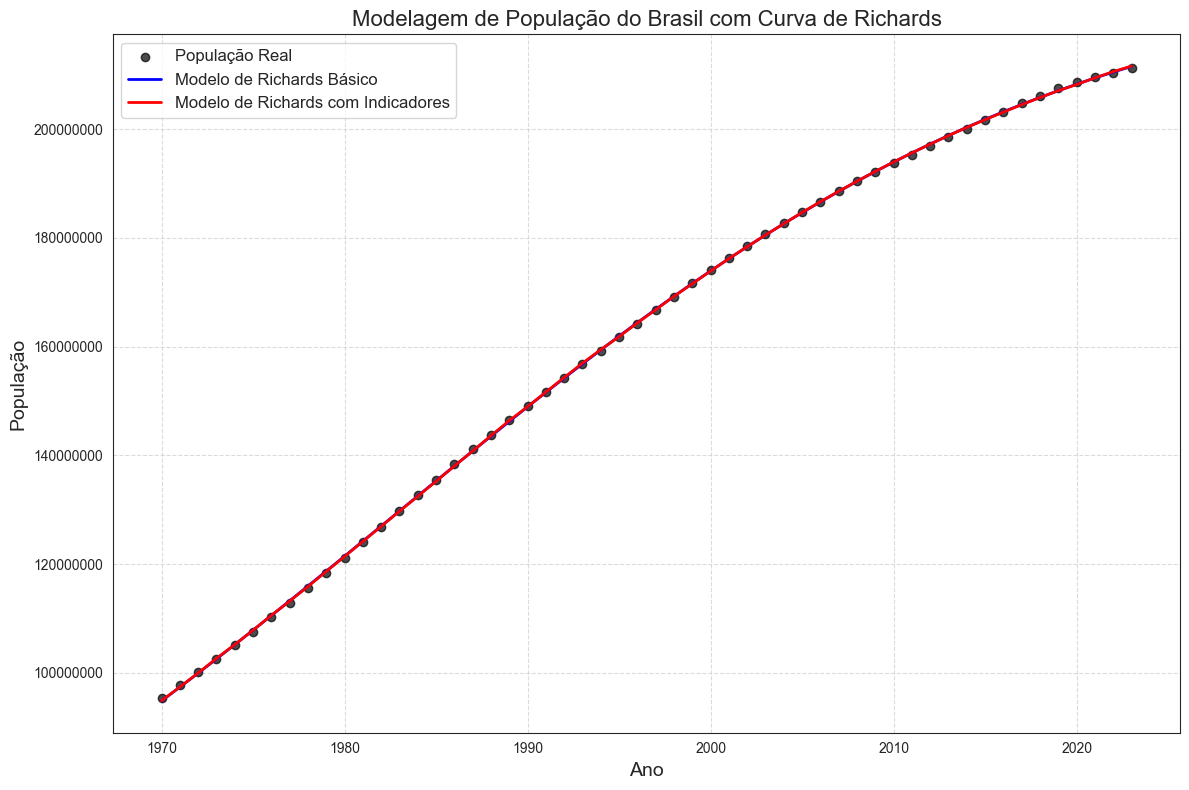

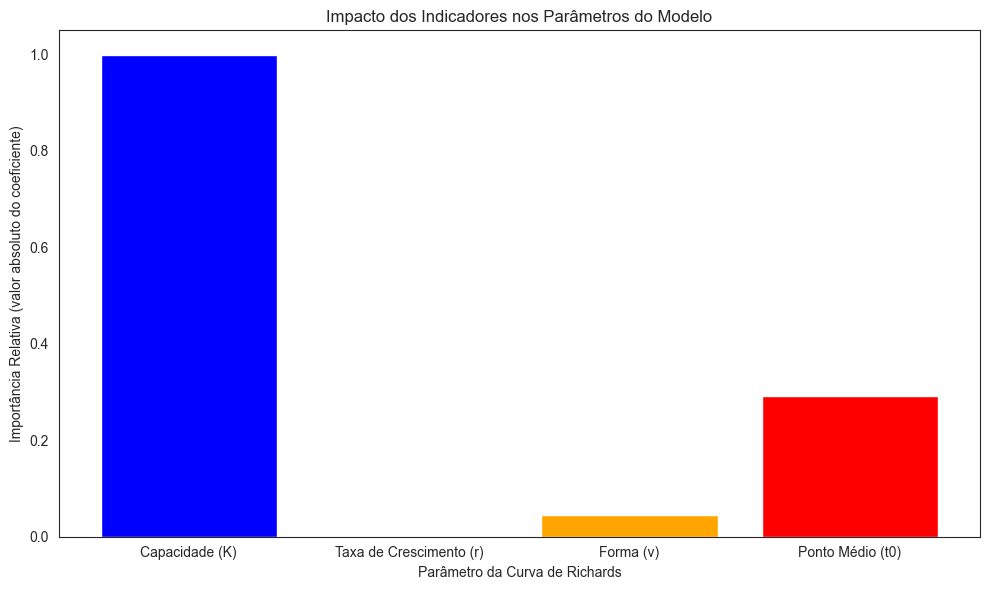


Interpretação do impacto dos indicadores:
Os indicadores Adjusted net national income (constant 2015 US$), Broad money (% of GDP), Adjusted savings: education expenditure (% of GNI), Communications, computer, etc. (% of service imports, BoP) têm maior impacto em:
- Capacidade (K) (coeficiente = 1.0000)
- Ponto Médio (t0) (coeficiente = 0.2929)
- Forma (v) (coeficiente = 0.0443)
- Taxa de Crescimento (r) (coeficiente = 0.0003)

Projeção de população para os próximos anos:
Ano        Modelo Básico        Modelo com Indicadores
--------------------------------------------------
2024       212,504,153          212,612,219         
2025       213,457,240          213,602,496         
2026       214,367,383          214,553,090         
2027       215,236,010          215,465,222         
2028       216,064,555          216,340,107         
2029       216,854,448          217,178,951         
2030       217,607,109          217,982,953         
2031       218,323,944          218,753,293   

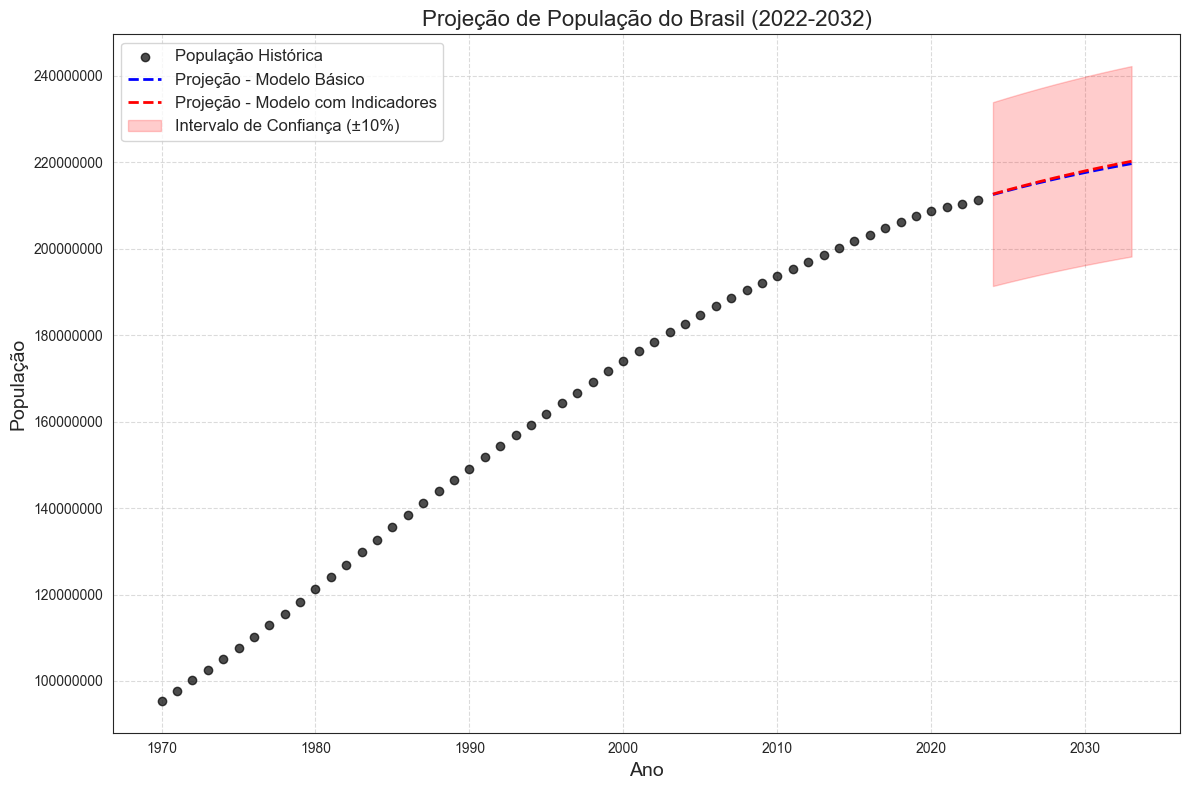


Modelagem concluída!


In [80]:
# Executar a modelagem
if __name__ == "__main__":
    resultados = executar_modelagem_richards()
    print("\nModelagem concluída!")

## Richards com pca

In [ ]:
# ==============================================================================
# FUNÇÕES BÁSICAS DA CURVA DE RICHARDS 
# ==============================================================================

def modelo_richards(t, K, r, v, t0):
    """
    Modelo de Richards: logístico generalizado com ponto de inflexão variável.
    """
    return K / (1 + v * np.exp(-r * (t - t0)))**(1/v)

# ==============================================================================
# SELEÇÃO E PREPARAÇÃO DOS PCs
# ==============================================================================

def extrair_pcs_por_macrotema(dfs_macrotema_unificado, df_brasil, n_components=3):
    """
    Extrai componentes principais organizados por macrotema para seleção posterior.
    
    Returns:
        dict: {macrotema: {'pcs': array, 'pca_obj': PCA, 'info': dict}}
    """
    pop_data = df_brasil['Population, total'].dropna()
    anos = pop_data.index.values
    
    resultados_pca = {}
    
    for macrotema, df_macro in dfs_macrotema_unificado.items():
        print(f"Processando PCA para {macrotema}...")
        
        # Alinhar com os anos da população
        df_aligned = df_macro.reindex(anos).interpolate(method='linear', limit_direction='both')
        
        if df_aligned.dropna().empty:
            print(f"  Saltando {macrotema} - dados insuficientes")
            continue
            
        # Padronizar dados
        scaler = StandardScaler()
        df_scaled = scaler.fit_transform(df_aligned.fillna(df_aligned.mean()))
        
        # Aplicar PCA
        n_comp = min(n_components, df_aligned.shape[1])
        pca = PCA(n_components=n_comp)
        pcs = pca.fit_transform(df_scaled)
        
        # Armazenar resultados
        resultados_pca[macrotema] = {
            'pcs': pcs,  # shape: (n_anos, n_components)
            'pca_obj': pca,
            'scaler': scaler,
            'info': {
                'explained_variance': pca.explained_variance_ratio_,
                'feature_names': df_aligned.columns.tolist(),
                'n_components': n_comp,
                'total_variance': pca.explained_variance_ratio_.sum()
            }
        }
        
        print(f"  ✓ {n_comp} componentes - Variância total: {pca.explained_variance_ratio_.sum():.2%}")
    
    return resultados_pca

def selecionar_pcs_especificos(resultados_pca, selecoes):
    """
    Seleciona PCs específicos baseado em uma lista de seleções.
    
    Args:
        resultados_pca: Resultado de extrair_pcs_por_macrotema
        selecoes: Lista de tuplas [(macrotema, pc_index), ...]
                 Ex: [('Health', 0), ('Financial Sector', 0), ('Economy', 1)]
    
    Returns:
        selected_pcs_matrix: array (n_anos, n_pcs_selecionados)
        pcs_info: lista com informações de cada PC selecionado
    """
    selected_pcs = []
    pcs_info = []
    
    for macrotema, pc_index in selecoes:
        if macrotema not in resultados_pca:
            print(f"Aviso: Macrotema '{macrotema}' não encontrado")
            continue
            
        pca_result = resultados_pca[macrotema]
        
        if pc_index >= pca_result['pcs'].shape[1]:
            print(f"Aviso: PC{pc_index+1} não existe para '{macrotema}' (max: PC{pca_result['pcs'].shape[1]})")
            continue
        
        # Extrair o PC específico
        pc_data = pca_result['pcs'][:, pc_index]
        selected_pcs.append(pc_data)
        
        # Informações do PC
        var_explicada = pca_result['info']['explained_variance'][pc_index]
        pcs_info.append({
            'macrotema': macrotema,
            'pc_index': pc_index,
            'nome': f"PC{pc_index+1}_{macrotema}",
            'variancia_explicada': var_explicada,
            'pca_obj': pca_result['pca_obj'],
            'feature_names': pca_result['info']['feature_names']
        })
        
        print(f"✓ Selecionado PC{pc_index+1} de {macrotema} (var: {var_explicada:.2%})")
    
    if not selected_pcs:
        print("Nenhum PC foi selecionado!")
        return np.empty((0, 0)), []
    
    selected_pcs_matrix = np.column_stack(selected_pcs)
    
    print(f"\nTotal de PCs selecionados: {len(pcs_info)}")
    print(f"Matriz final: {selected_pcs_matrix.shape}")
    
    return selected_pcs_matrix, pcs_info

def sugerir_pcs_relevantes(resultados_pca, top_n=5):
    """
    Sugere os PCs mais relevantes baseado na variância explicada.
    """
    sugestoes = []
    
    for macrotema, resultado in resultados_pca.items():
        for i, var_exp in enumerate(resultado['info']['explained_variance']):
            sugestoes.append({
                'macrotema': macrotema,
                'pc_index': i,
                'variancia': var_exp,
                'nome': f"PC{i+1}_{macrotema}"
            })
    
    # Ordenar por variância explicada
    sugestoes.sort(key=lambda x: x['variancia'], reverse=True)
    
    print(f"\n=== TOP {top_n} PCs POR VARIÂNCIA EXPLICADA ===")
    for i, sugestao in enumerate(sugestoes[:top_n]):
        print(f"{i+1}. {sugestao['nome']} - {sugestao['variancia']:.2%}")
    
    return sugestoes[:top_n]

# ==============================================================================
# MODELO RICHARDS COM PCs DETALHADOS
# ==============================================================================

def modelo_richards_com_pcs_detalhado(t, K_base, r_base, v_base, t0_base, 
                                     *args):
    """
    Modelo de Richards onde cada PC selecionado tem coeficientes individuais
    para cada parâmetro (K, r, v, t0).
    
    Args:
        t: tempo
        K_base, r_base, v_base, t0_base: valores base dos parâmetros
        *args: [coefs_K (M valores), coefs_r (M valores), coefs_v (M valores), 
                coefs_t0 (M valores), pcs_matrix_flat (M*N valores)]
               onde M = número de PCs selecionados, N = número de pontos no tempo
    """
    n_points = len(t)
    
    # Determinar quantos PCs temos
    # args contém: M coefs para K + M coefs para r + M coefs para v + M coefs para t0 + M*N valores dos PCs
    # Total de args = 4*M + M*N = M*(4 + N)
    # Resolvendo: M = len(args) / (4 + N)
    
    total_args = len(args)
    M = int(total_args / (4 + n_points))
    
    if M == 0:
        # Sem PCs, usar modelo básico
        return modelo_richards(t, K_base, r_base, v_base, t0_base)
    
    # Extrair coeficientes
    coefs_K = np.array(args[:M])
    coefs_r = np.array(args[M:2*M])
    coefs_v = np.array(args[2*M:3*M])
    coefs_t0 = np.array(args[3*M:4*M])
    
    # Extrair e reconstruir matriz de PCs
    pcs_flat = args[4*M:]
    pcs_matrix = np.array(pcs_flat).reshape(M, n_points).T
    
    # Calcular influência dos PCs em cada parâmetro
    K_influence = np.dot(pcs_matrix, coefs_K)
    r_influence = np.dot(pcs_matrix, coefs_r)
    v_influence = np.dot(pcs_matrix, coefs_v)
    t0_influence = np.dot(pcs_matrix, coefs_t0)
    
    # Calcular parâmetros finais
    K = K_base + K_influence
    r = r_base + r_influence
    v = v_base + v_influence
    t0 = t0_base + t0_influence
    
    # Aplicar restrições para manter parâmetros válidos
    K = np.maximum(K, 1e5)  # Capacidade mínima
    r = np.clip(r, 0.001, 1.0)  # Taxa de crescimento válida
    v = np.maximum(v, 0.001)  # v positivo
    
    # Calcular modelo ponto a ponto
    pop = np.zeros_like(t, dtype=float)
    for i in range(len(t)):
        try:
            pop[i] = modelo_richards(t[i], K[i], r[i], v[i], t0[i])
        except:
            pop[i] = K[i] / (1 + v[i])  # Valor aproximado em caso de erro
    
    return pop

# ==============================================================================
# AJUSTE DO MODELO DETALHADO
# ==============================================================================

def ajustar_modelo_richards_com_pcs_detalhado(X, y, selected_pcs_matrix, pcs_info):
    """
    Ajusta o modelo de Richards com PCs individuais.
    
    Args:
        X: anos normalizados
        y: população
        selected_pcs_matrix: matriz com os PCs selecionados (n_anos, n_pcs)
        pcs_info: informações dos PCs selecionados
    
    Returns:
        dict: parâmetros ajustados organizados
        array: predições do modelo
    """
    if selected_pcs_matrix.shape[1] == 0:
        print("Nenhum PC disponível, usando modelo básico")
        from . import ajustar_modelo_richards_basico  # Assumindo que existe
        return ajustar_modelo_richards_basico(X, y)
    
    M = selected_pcs_matrix.shape[1]  # Número de PCs
    N = len(X)  # Número de pontos no tempo
    
    print(f"Ajustando modelo com {M} PCs selecionados...")
    
    # Achatar matriz de PCs para passar ao curve_fit
    pcs_flat = selected_pcs_matrix.T.flatten()
    
    def modelo_wrapper(t, K_base, r_base, v_base, t0_base, 
                      *coefs_all):
        """Wrapper para curve_fit"""
        # Combinar todos os argumentos
        all_args = list(coefs_all) + list(pcs_flat)
        return modelo_richards_com_pcs_detalhado(
            t, K_base, r_base, v_base, t0_base, *all_args
        )
    
    # Definir parâmetros iniciais
    # 4 parâmetros base + 4*M coeficientes dos PCs
    p0 = [
        y.max() * 0.8,  # K_base
        0.02,           # r_base
        0.5,            # v_base
        X.mean()        # t0_base
    ]
    
    # Coeficientes iniciais pequenos para os PCs
    for _ in range(4 * M):  # 4 coeficientes por PC (K, r, v, t0)
        p0.append(0.01)
    
    # Definir bounds
    bounds_lower = [
        y.max() * 0.5,  # K_base mín
        0.001,          # r_base mín
        0.001,          # v_base mín
        0               # t0_base mín
    ]
    bounds_upper = [
        y.max() * 2.0,  # K_base máx
        0.1,            # r_base máx
        10,             # v_base máx
        X.max()         # t0_base máx
    ]
    
    # Bounds para coeficientes dos PCs
    for _ in range(4 * M):
        bounds_lower.append(-1.0)  # Coef mín (pode ser negativo)
        bounds_upper.append(1.0)   # Coef máx
    
    try:
        params_opt, _ = curve_fit(
            modelo_wrapper, X, y, p0=p0,
            bounds=(bounds_lower, bounds_upper),
            method='trf', maxfev=20000
        )
        
        print("✓ Ajuste concluído com sucesso")
        
    except Exception as e:
        print(f"Erro no curve_fit: {e}")
        print("Tentando com differential_evolution...")
        
        def objective(params):
            try:
                y_pred = modelo_wrapper(X, *params)
                return np.sum((y - y_pred)**2)
            except:
                return 1e10
        
        bounds_de = list(zip(bounds_lower, bounds_upper))
        result = differential_evolution(
            objective, bounds_de, maxiter=1000, popsize=20
        )
        params_opt = result.x
        print("✓ Ajuste concluído com differential_evolution")
    
    # Calcular predições
    y_pred = modelo_wrapper(X, *params_opt)
    
    # Organizar parâmetros de forma estruturada
    params_organizados = {
        'K_base': params_opt[0],
        'r_base': params_opt[1], 
        'v_base': params_opt[2],
        't0_base': params_opt[3],
        'coefs': {
            'K': params_opt[4:4+M],
            'r': params_opt[4+M:4+2*M],
            'v': params_opt[4+2*M:4+3*M],
            't0': params_opt[4+3*M:4+4*M]
        },
        'pcs_info': pcs_info,
        'n_pcs': M
    }
    
    return params_organizados, y_pred

# ==============================================================================
# VISUALIZAÇÃO MELHORADA
# ==============================================================================

def plotar_coeficientes_pcs_detalhado(params_organizados):
    """
    Plota os coeficientes individuais de cada PC para cada parâmetro.
    """
    if params_organizados['n_pcs'] == 0:
        print("Nenhum PC para plotar")
        return
    
    coefs = params_organizados['coefs']
    pcs_info = params_organizados['pcs_info']
    
    # Nomes dos PCs para labels
    pc_names = [info['nome'] for info in pcs_info]
    
    # Criar subplots
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('Coeficientes dos PCs nos Parâmetros de Richards', fontsize=16)
    
    parametros = ['K (Capacidade)', 'r (Taxa de Crescimento)', 'v (Forma)', 't0 (Ponto Médio)']
    coef_keys = ['K', 'r', 'v', 't0']
    colors = ['blue', 'green', 'orange', 'red']
    
    for i, (ax, param_name, coef_key, color) in enumerate(zip(axes.flat, parametros, coef_keys, colors)):
        coef_values = coefs[coef_key]
        
        bars = ax.bar(range(len(pc_names)), coef_values, color=color, alpha=0.7)
        ax.set_title(f'Impacto dos PCs em {param_name}')
        ax.set_xlabel('Componentes Principais')
        ax.set_ylabel('Coeficiente')
        ax.set_xticks(range(len(pc_names)))
        ax.set_xticklabels(pc_names, rotation=45, ha='right')
        ax.grid(True, alpha=0.3)
        ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
        
        # Adicionar valores nas barras
        for bar, value in zip(bars, coef_values):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., 
                   height + (0.01 if height >= 0 else -0.02),
                   f'{value:.3f}', ha='center', 
                   va='bottom' if height >= 0 else 'top')
    
    plt.tight_layout()
    plt.show()

def plotar_loadings_pcs_relevantes(params_organizados, threshold=0.1):
    """
    Plota os loadings dos PCs que têm coeficientes significativos.
    """
    if params_organizados['n_pcs'] == 0:
        return
    
    # Identificar PCs com coeficientes significativos
    pcs_relevantes = []
    coefs = params_organizados['coefs']
    
    for i, pc_info in enumerate(params_organizados['pcs_info']):
        # Verificar se algum coeficiente é significativo
        max_coef = max(abs(coefs['K'][i]), abs(coefs['r'][i]), 
                      abs(coefs['v'][i]), abs(coefs['t0'][i]))
        
        if max_coef > threshold:
            pcs_relevantes.append((i, pc_info, max_coef))
    
    if not pcs_relevantes:
        print(f"Nenhum PC com coeficiente > {threshold}")
        return
    
    print(f"\n=== PCs RELEVANTES (coef > {threshold}) ===")
    
    for i, (pc_idx, pc_info, max_coef) in enumerate(pcs_relevantes):
        print(f"\n{pc_info['nome']} (coef máx: {max_coef:.3f}):")
        
        # Obter loadings
        pca_obj = pc_info['pca_obj']
        pc_index = pc_info['pc_index']
        feature_names = pc_info['feature_names']
        
        loadings = pca_obj.components_[pc_index]
        
        # Plotar loadings
        plt.figure(figsize=(12, 6))
        bars = plt.bar(range(len(loadings)), loadings, alpha=0.7)
        plt.title(f'Loadings do {pc_info["nome"]}')
        plt.xlabel('Indicadores')
        plt.ylabel('Loading')
        plt.xticks(range(len(feature_names)), feature_names, rotation=45, ha='right')
        plt.grid(True, alpha=0.3)
        plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
        
        # Destacar loadings mais importantes
        for j, (bar, loading) in enumerate(zip(bars, loadings)):
            if abs(loading) > 0.3:  # Threshold para loadings importantes
                bar.set_color('red' if loading > 0 else 'darkred')
                bar.set_alpha(0.8)
        
        plt.tight_layout()
        plt.show()
        
        # Mostrar loadings mais importantes numericamente
        loading_importance = [(abs(l), i, l) for i, l in enumerate(loadings)]
        loading_importance.sort(reverse=True)
        
        print("  Indicadores mais importantes:")
        for abs_load, feat_idx, load in loading_importance[:5]:
            print(f"    {feature_names[feat_idx]}: {load:.3f}")

# ==============================================================================
# FUNÇÃO PRINCIPAL INTEGRADA
# ==============================================================================

def executar_modelagem_richards_pcs_detalhado(df_brasil, dfs_macrotema_unificado, 
                                            selecoes_pcs=None, auto_select=True):
    """
    Executa a modelagem de Richards com PCs individuais selecionáveis.
    
    Args:
        df_brasil: DataFrame com dados do Brasil
        dfs_macrotema_unificado: Dicionário com DataFrames por macrotema  
        selecoes_pcs: Lista de tuplas [(macrotema, pc_index), ...] ou None
        auto_select: Se True, seleciona automaticamente os top PCs
    """
    print("=== MODELAGEM DE RICHARDS COM PCs DETALHADOS ===")
    
    try:
        # 1. Extrair PCs por macrotema
        print("\n1. Extraindo componentes principais por macrotema...")
        resultados_pca = extrair_pcs_por_macrotema(dfs_macrotema_unificado, df_brasil)
        
        if not resultados_pca:
            print("Erro: Nenhum PCA foi gerado")
            return None
        
        # 2. Selecionar PCs específicos
        print("\n2. Selecionando componentes principais...")
        
        if selecoes_pcs is None:
            if auto_select:
                # Seleção automática dos top PCs
                sugestoes = sugerir_pcs_relevantes(resultados_pca, top_n=5)
                selecoes_pcs = [(s['macrotema'], s['pc_index']) for s in sugestoes[:3]]
                print(f"Seleção automática: {selecoes_pcs}")
            else:
                print("Nenhuma seleção fornecida e auto_select=False")
                return None
        
        selected_pcs_matrix, pcs_info = selecionar_pcs_especificos(resultados_pca, selecoes_pcs)
        
        if selected_pcs_matrix.shape[1] == 0:
            print("Erro: Nenhum PC foi selecionado com sucesso")
            return None
        
        # 3. Preparar dados da população
        pop_data = df_brasil['Population, total'].dropna()
        anos = pop_data.index.values
        X = anos - anos.min()
        y = pop_data.values
        anos_reais = anos
        
        print(f"\nDados preparados:")
        print(f"- Período: {anos_reais.min():.0f} a {anos_reais.max():.0f}")
        print(f"- Observações: {len(X)}")
        print(f"- PCs selecionados: {selected_pcs_matrix.shape[1]}")
        
        # 4. Ajustar modelo básico (para comparação)
        print("\n3. Ajustando modelo básico...")
        def ajustar_modelo_richards_basico_local(X, y):
            p0 = [y.max() * 1.2, 0.03, 0.5, X.mean()]
            bounds = [(y.max(), y.max() * 5), (0.001, 0.5), (0.001, 10), (0, X.max())]
            
            try:
                params, _ = curve_fit(
                    modelo_richards, X, y, p0=p0,
                    bounds=([b[0] for b in bounds], [b[1] for b in bounds]),
                    method='trf', maxfev=10000
                )
            except:
                def obj_func(params):
                    y_pred = modelo_richards(X, *params)
                    return np.sum((y - y_pred)**2)
                
                result = differential_evolution(obj_func, bounds, maxiter=1000, popsize=20)
                params = result.x
            
            y_pred = modelo_richards(X, *params)
            return params, y_pred
        
        params_basico, y_pred_basico = ajustar_modelo_richards_basico_local(X, y)
        
        # 5. Ajustar modelo com PCs detalhados
        print("\n4. Ajustando modelo com PCs detalhados...")
        params_pcs_detalhado, y_pred_pcs_detalhado = ajustar_modelo_richards_com_pcs_detalhado(
            X, y, selected_pcs_matrix, pcs_info
        )
        
        # 6. Avaliar modelos
        print("\n5. Avaliando modelos...")
        def avaliar_modelo_local(y_true, y_pred, nome_modelo):
            mse = mean_squared_error(y_true, y_pred)
            rmse = np.sqrt(mse)
            r2 = r2_score(y_true, y_pred)
            
            print(f"\nAvaliação do modelo {nome_modelo}:")
            print(f"MSE: {mse:.2f}")
            print(f"RMSE: {rmse:.2f}")
            print(f"R²: {r2:.4f}")
            
            return {"MSE": mse, "RMSE": rmse, "R2": r2}
        
        metricas_basico = avaliar_modelo_local(y, y_pred_basico, "Básico")
        metricas_pcs_detalhado = avaliar_modelo_local(y, y_pred_pcs_detalhado, "PCs Detalhados")
        
        # 7. Plot de resíduos do modelo detalhado
        residuos = y - y_pred_pcs_detalhado
        plt.figure(figsize=(10, 4))
        plt.plot(anos_reais, residuos, marker='o', linestyle='--')
        plt.axhline(0, color='black', linewidth=0.8)
        plt.title("Resíduos do Modelo com PCs Detalhados")
        plt.xlabel("Ano")
        plt.ylabel("Erro (População Real - Prevista)")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

        # 8. Visualizar resultados
        print("\n6. Gerando visualizações...")
        
        # Plot comparativo
        plt.figure(figsize=(14, 8))
        plt.scatter(anos_reais, y, color='black', label='População Real', alpha=0.7, s=50)
        plt.plot(anos_reais, y_pred_basico, 'b-', linewidth=2, label='Modelo Básico')
        plt.plot(anos_reais, y_pred_pcs_detalhado, 'r-', linewidth=2, label='Modelo PCs Detalhados')
        
        plt.title('Modelagem de População do Brasil: Básico vs PCs Detalhados', fontsize=16)
        plt.xlabel('Ano', fontsize=14)
        plt.ylabel('População', fontsize=14)
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.legend(fontsize=12)
        plt.ticklabel_format(axis='y', style='plain')
        plt.tight_layout()
        plt.show()
        
        # Plot dos coeficientes
        plotar_coeficientes_pcs_detalhado(params_pcs_detalhado)
        
        # Plot dos loadings dos PCs relevantes
        plotar_loadings_pcs_relevantes(params_pcs_detalhado)
        
        # 8. Resumo dos resultados
        print(f"\n=== RESUMO DOS RESULTADOS ===")
        print(f"Modelo Básico - R²: {metricas_basico['R2']:.4f}")
        print(f"Modelo PCs Detalhados - R²: {metricas_pcs_detalhado['R2']:.4f}")
        
        if metricas_pcs_detalhado['R2'] > metricas_basico['R2']:
            print("✓ O modelo com PCs detalhados apresentou melhor performance!")
            melhoria = (metricas_pcs_detalhado['R2'] - metricas_basico['R2']) * 100
            print(f"  Melhoria no R²: +{melhoria:.2f} pontos percentuais")
        else:
            print("⚠ O modelo básico ainda apresenta melhor performance")
        
        # Resumo dos PCs selecionados
        print(f"\n=== PCs SELECIONADOS ===")
        for info in pcs_info:
            print(f"- {info['nome']}: {info['variancia_explicada']:.2%} de variância")
        
        return {
            'params_basico': params_basico,
            'params_pcs_detalhado': params_pcs_detalhado,
            'metricas_basico': metricas_basico,
            'metricas_pcs_detalhado': metricas_pcs_detalhado,
            'pcs_info': pcs_info,
            'resultados_pca': resultados_pca,
            'anos': anos_reais,
            'populacao_real': y,
            'pred_basico': y_pred_basico,
            'pred_pcs_detalhado': y_pred_pcs_detalhado
        }
        
    except Exception as e:
        print(f"Erro na modelagem: {e}")
        import traceback
        traceback.print_exc()
        return None



=== MODELAGEM DE RICHARDS COM PCs DETALHADOS ===

1. Extraindo componentes principais por macrotema...
Processando PCA para Economic Policy & Debt...
  ✓ 3 componentes - Variância total: 78.71%
Processando PCA para Environment...
  ✓ 3 componentes - Variância total: 73.18%
Processando PCA para Financial Sector...
  ✓ 3 componentes - Variância total: 88.80%
Processando PCA para Health...
  ✓ 3 componentes - Variância total: 99.84%
Processando PCA para Private Sector & Trade...
  ✓ 3 componentes - Variância total: 85.25%
Processando PCA para Public Sector...
  ✓ 3 componentes - Variância total: 100.00%
Processando PCA para Social Protection & Labor...
  ✓ 1 componentes - Variância total: 100.00%

2. Selecionando componentes principais...

=== TOP 5 PCs POR VARIÂNCIA EXPLICADA ===
1. PC1_Social Protection & Labor - 100.00%
2. PC1_Health - 66.79%
3. PC1_Economic Policy & Debt - 61.82%
4. PC1_Financial Sector - 57.96%
5. PC1_Public Sector - 49.54%
Seleção automática: [('Social Protection & 

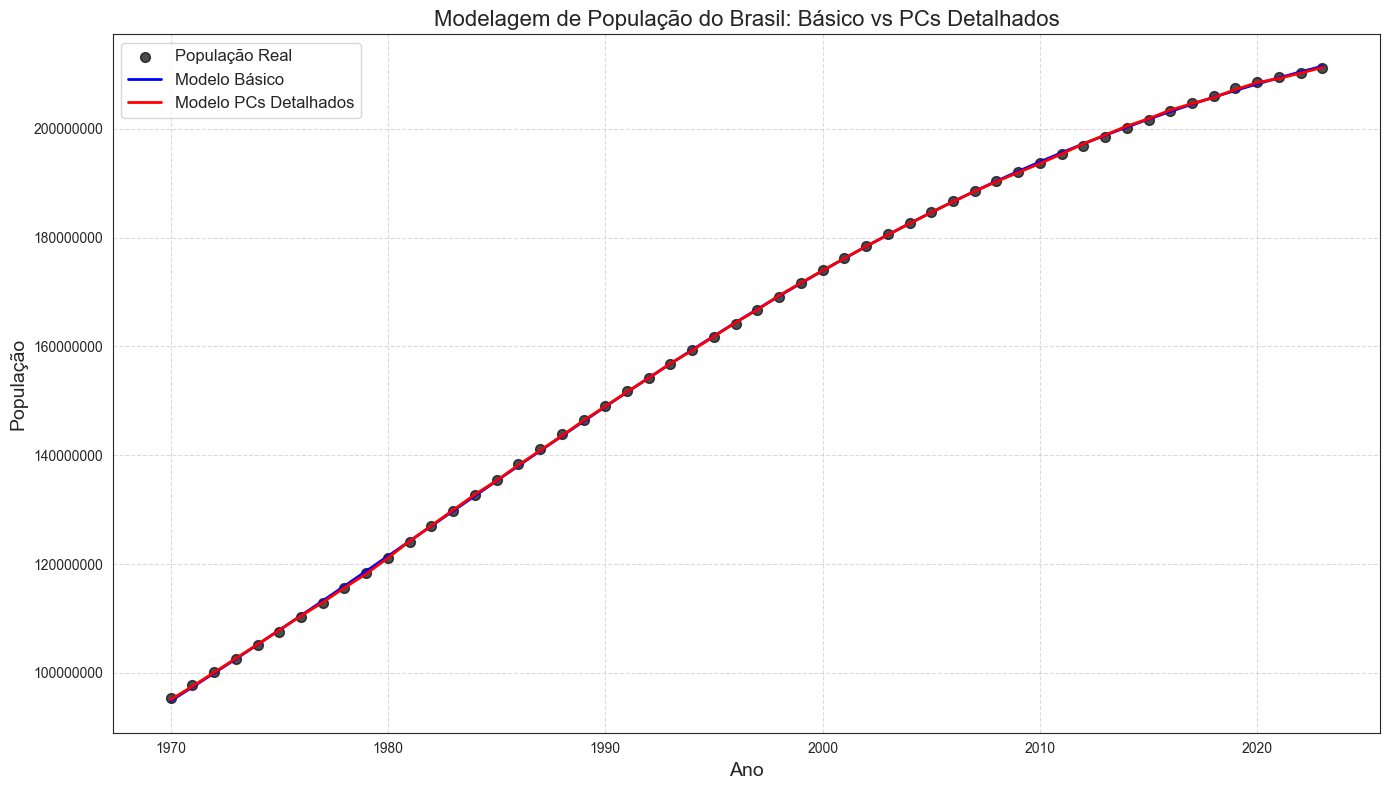

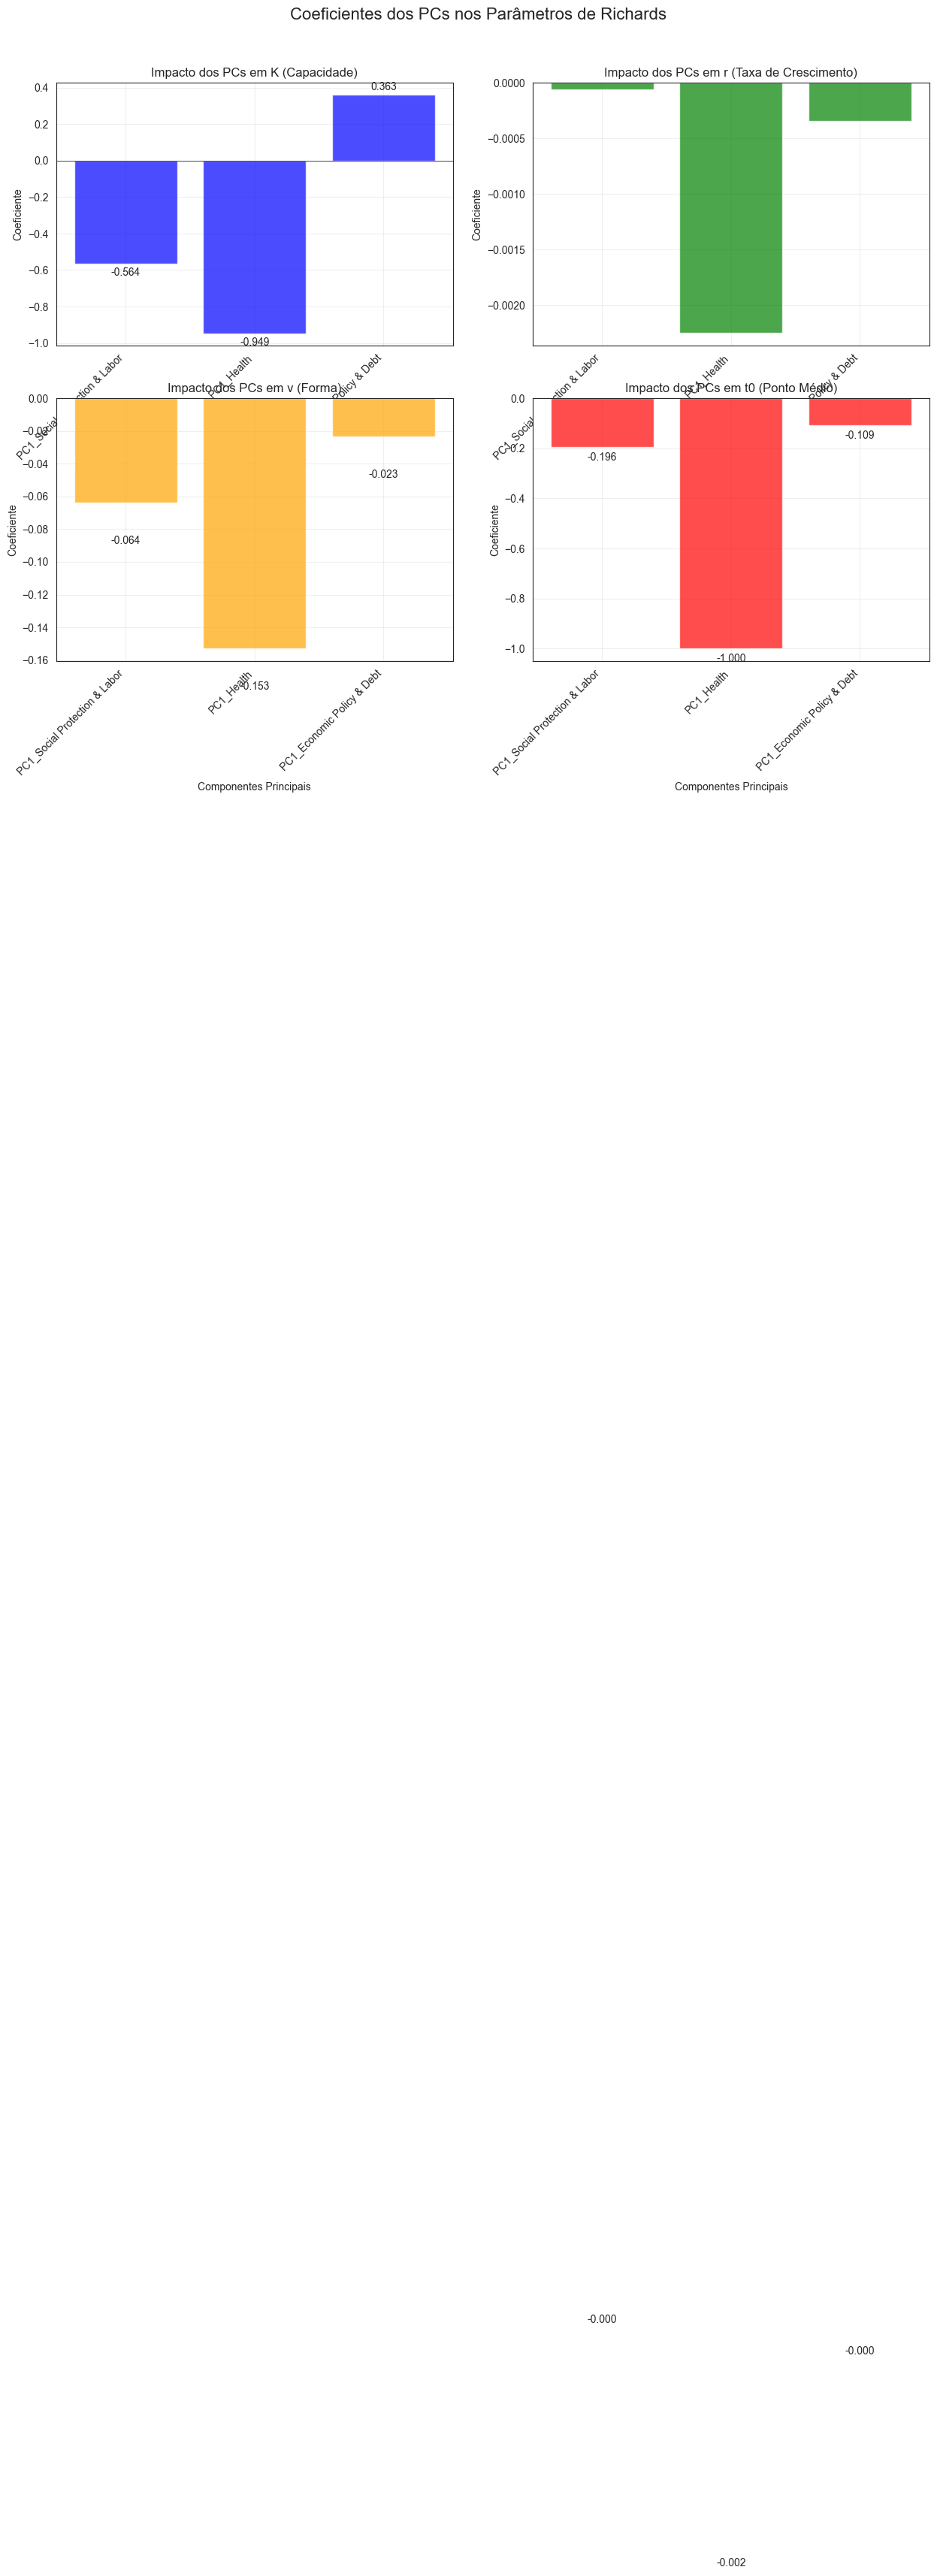


=== PCs RELEVANTES (coef > 0.1) ===

PC1_Social Protection & Labor (coef máx: 0.564):


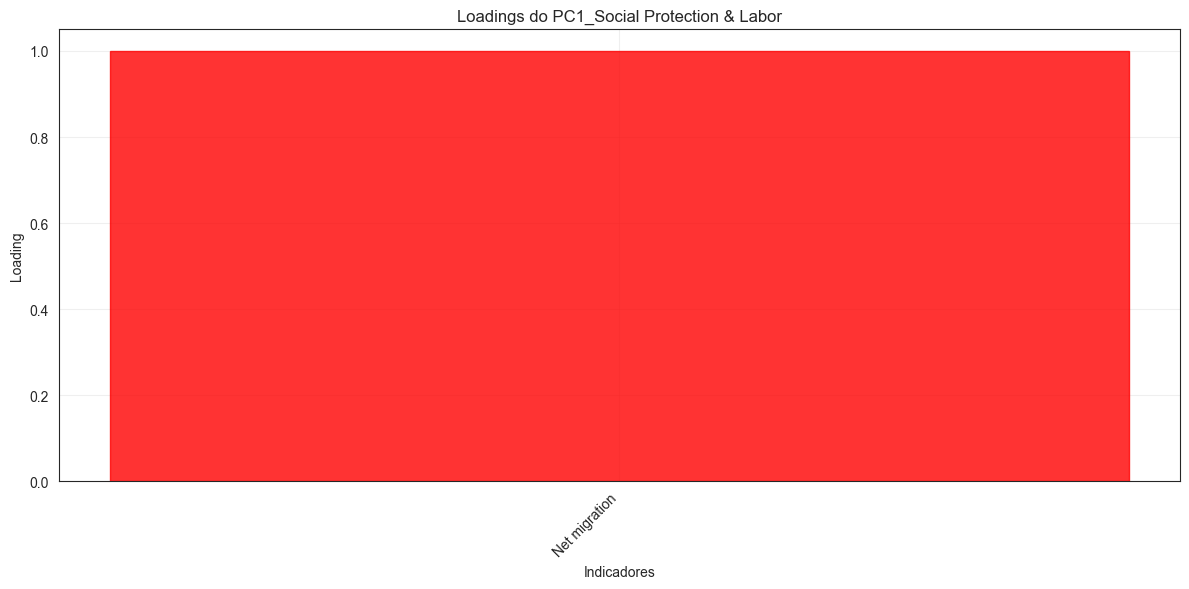

  Indicadores mais importantes:
    Net migration: 1.000

PC1_Health (coef máx: 1.000):


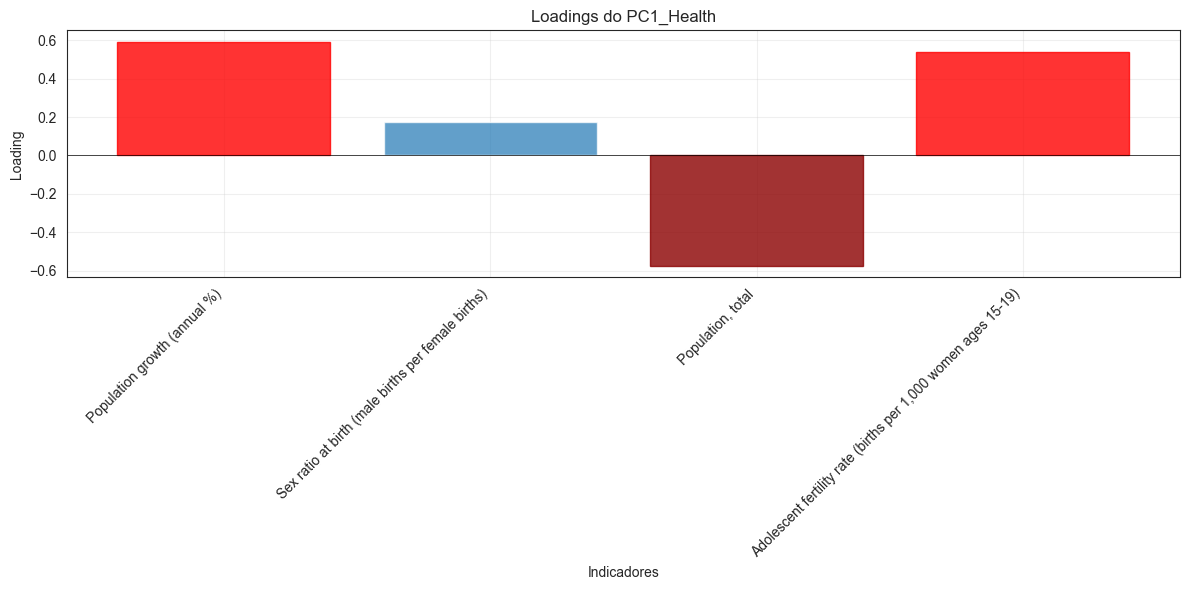

  Indicadores mais importantes:
    Population growth (annual %): 0.592
    Population, total: -0.575
    Adolescent fertility rate (births per 1,000 women ages 15-19): 0.537
    Sex ratio at birth (male births per female births): 0.174

PC1_Economic Policy & Debt (coef máx: 0.363):


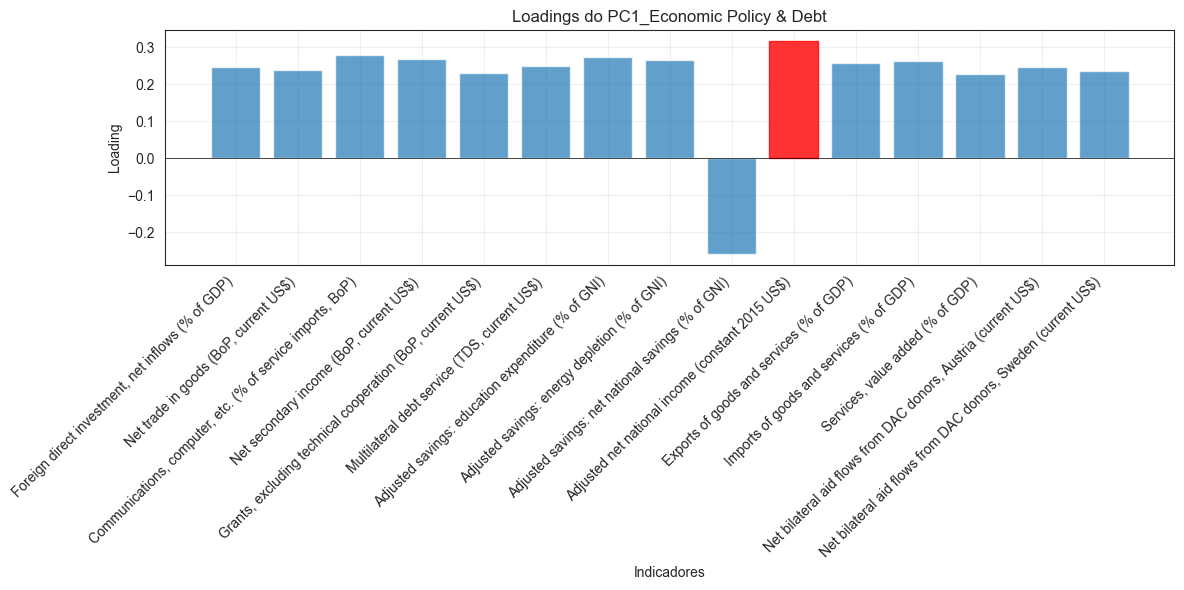

  Indicadores mais importantes:
    Adjusted net national income (constant 2015 US$): 0.317
    Communications, computer, etc. (% of service imports, BoP): 0.280
    Adjusted savings: education expenditure (% of GNI): 0.274
    Net secondary income (BoP, current US$): 0.268
    Adjusted savings: energy depletion (% of GNI): 0.266

=== RESUMO DOS RESULTADOS ===
Modelo Básico - R²: 1.0000
Modelo PCs Detalhados - R²: 1.0000
✓ O modelo com PCs detalhados apresentou melhor performance!
  Melhoria no R²: +0.00 pontos percentuais

=== PCs SELECIONADOS ===
- PC1_Social Protection & Labor: 100.00% de variância
- PC1_Health: 66.79% de variância
- PC1_Economic Policy & Debt: 61.82% de variância


{'params_basico': array([2.31391058e+08, 5.78679275e-02, 1.69471762e+00, 1.26929988e+01]),
 'params_pcs_detalhado': {'K_base': np.float64(225947195.2715882),
  'r_base': np.float64(0.07088455654420173),
  'v_base': np.float64(2.484600574059797),
  't0_base': np.float64(15.942074500244528),
  'coefs': {'K': array([-0.56438897, -0.94860691,  0.36310346]),
   'r': array([-6.23953655e-05, -2.25095119e-03, -3.43804257e-04]),
   'v': array([-0.06379649, -0.1529375 , -0.02347469]),
   't0': array([-0.19593658, -1.        , -0.1090376 ])},
  'pcs_info': [{'macrotema': 'Social Protection & Labor',
    'pc_index': 0,
    'nome': 'PC1_Social Protection & Labor',
    'variancia_explicada': np.float64(1.0),
    'pca_obj': PCA(n_components=1),
    'feature_names': ['Net migration']},
   {'macrotema': 'Health',
    'pc_index': 0,
    'nome': 'PC1_Health',
    'variancia_explicada': np.float64(0.6678942769386516),
    'pca_obj': PCA(n_components=3),
    'feature_names': ['Population growth (annual %)'

In [90]:
executar_modelagem_richards_pcs_detalhado(new_df_brasil_wide, dfs_macrotema_unificado)